# IMPORTING LIBRARIES

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

app_data = pd.read_csv('application_data.csv')

# READ APPLICATION

## DATA INSPECTION

In [93]:
app_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


## DATA QUALITY CHECK

In [94]:
pd.set_option("display.max_rows", 200)
app_data.isnull().mean()*100

SK_ID_CURR                       0.000000
TARGET                           0.000000
NAME_CONTRACT_TYPE               0.000000
CODE_GENDER                      0.000000
FLAG_OWN_CAR                     0.000000
FLAG_OWN_REALTY                  0.000000
CNT_CHILDREN                     0.000000
AMT_INCOME_TOTAL                 0.000000
AMT_CREDIT                       0.000000
AMT_ANNUITY                      0.003902
AMT_GOODS_PRICE                  0.090403
NAME_TYPE_SUITE                  0.420148
NAME_INCOME_TYPE                 0.000000
NAME_EDUCATION_TYPE              0.000000
NAME_FAMILY_STATUS               0.000000
NAME_HOUSING_TYPE                0.000000
REGION_POPULATION_RELATIVE       0.000000
DAYS_BIRTH                       0.000000
DAYS_EMPLOYED                    0.000000
DAYS_REGISTRATION                0.000000
DAYS_ID_PUBLISH                  0.000000
OWN_CAR_AGE                     65.990810
FLAG_MOBIL                       0.000000
FLAG_EMP_PHONE                   0

- CONCLUSION : Columns with null values more than 47% may give wrong insights hence we will drop them

## DROPPING COLUMNS WITH MISSING VALUES GREATER THAN 47%

In [95]:
percentage = 47
threshold = int((1 - percentage / 100) * app_data.shape[0])
app_df = app_data.dropna(axis=1, thresh=threshold)
app_df.head()


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [96]:
app_df.shape

(307511, 73)

In [97]:
app_data.isnull().mean()*100

SK_ID_CURR                       0.000000
TARGET                           0.000000
NAME_CONTRACT_TYPE               0.000000
CODE_GENDER                      0.000000
FLAG_OWN_CAR                     0.000000
FLAG_OWN_REALTY                  0.000000
CNT_CHILDREN                     0.000000
AMT_INCOME_TOTAL                 0.000000
AMT_CREDIT                       0.000000
AMT_ANNUITY                      0.003902
AMT_GOODS_PRICE                  0.090403
NAME_TYPE_SUITE                  0.420148
NAME_INCOME_TYPE                 0.000000
NAME_EDUCATION_TYPE              0.000000
NAME_FAMILY_STATUS               0.000000
NAME_HOUSING_TYPE                0.000000
REGION_POPULATION_RELATIVE       0.000000
DAYS_BIRTH                       0.000000
DAYS_EMPLOYED                    0.000000
DAYS_REGISTRATION                0.000000
DAYS_ID_PUBLISH                  0.000000
OWN_CAR_AGE                     65.990810
FLAG_MOBIL                       0.000000
FLAG_EMP_PHONE                   0

## CHECKING THE MISSING VALUES IN APPLICATION DATASET

In [98]:
app_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 73 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   307511 non-null  int64  
 1   TARGET                       307511 non-null  int64  
 2   NAME_CONTRACT_TYPE           307511 non-null  object 
 3   CODE_GENDER                  307511 non-null  object 
 4   FLAG_OWN_CAR                 307511 non-null  object 
 5   FLAG_OWN_REALTY              307511 non-null  object 
 6   CNT_CHILDREN                 307511 non-null  int64  
 7   AMT_INCOME_TOTAL             307511 non-null  float64
 8   AMT_CREDIT                   307511 non-null  float64
 9   AMT_ANNUITY                  307499 non-null  float64
 10  AMT_GOODS_PRICE              307233 non-null  float64
 11  NAME_TYPE_SUITE              306219 non-null  object 
 12  NAME_INCOME_TYPE             307511 non-null  object 
 13 

In [99]:
app_df.OCCUPATION_TYPE.isnull().mean()*100

np.float64(31.345545362604916)

In [100]:
app_df.OCCUPATION_TYPE.value_counts(normalize=True) * 100


OCCUPATION_TYPE
Laborers                 26.139636
Sales staff              15.205570
Core staff               13.058924
Managers                 10.122679
Drivers                   8.811576
High skill tech staff     5.390299
Accountants               4.648067
Medicine staff            4.043672
Security staff            3.183498
Cooking staff             2.816408
Cleaning staff            2.203960
Private service staff     1.256158
Low-skill Laborers        0.991379
Waiters/barmen staff      0.638499
Secretaries               0.618132
Realty agents             0.355722
HR staff                  0.266673
IT staff                  0.249147
Name: proportion, dtype: float64

In [101]:
app_df.OCCUPATION_TYPE.fillna("others", inplace = True)

In [102]:
app_df.OCCUPATION_TYPE.isnull().mean()*100

np.float64(0.0)

In [103]:
app_df.EXT_SOURCE_3.isnull().mean()*100

np.float64(19.825307062186393)

In [104]:
app_df.EXT_SOURCE_3.value_counts(normalize = True)*100

EXT_SOURCE_3
0.746300    0.592182
0.713631    0.533369
0.694093    0.517550
0.670652    0.483074
0.652897    0.468067
              ...   
0.028275    0.000406
0.858178    0.000406
0.849170    0.000406
0.887664    0.000406
0.864212    0.000406
Name: proportion, Length: 814, dtype: float64

In [105]:
app_df.EXT_SOURCE_3.describe()

count    246546.000000
mean          0.510853
std           0.194844
min           0.000527
25%           0.370650
50%           0.535276
75%           0.669057
max           0.896010
Name: EXT_SOURCE_3, dtype: float64

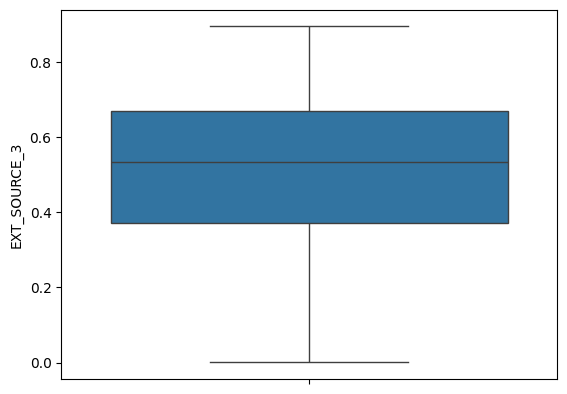

In [106]:
sns.boxplot(app_df.EXT_SOURCE_3)
plt.show()

In [107]:
app_df.EXT_SOURCE_3.fillna(app_df.EXT_SOURCE_3.median(), inplace = True)

In [108]:
app_df.EXT_SOURCE_3.isnull().mean()*100

np.float64(0.0)

In [109]:
app_df.EXT_SOURCE_3.value_counts(normalize = True)*100

EXT_SOURCE_3
0.535276    20.080908
0.746300     0.474780
0.713631     0.427627
0.694093     0.414945
0.670652     0.387303
              ...    
0.028275     0.000325
0.858178     0.000325
0.849170     0.000325
0.887664     0.000325
0.864212     0.000325
Name: proportion, Length: 814, dtype: float64

- CONCLUSION : Since it's numerical column with no outliers and therre is no much difference between mean and median. Hence we can impute with mean or median 

In [110]:
app_df.EXT_SOURCE_3.fillna(app_df.EXT_SOURCE_3.median(), inplace = True)

In [111]:
app_df.EXT_SOURCE_3.isnull().mean()*100

np.float64(0.0)

In [112]:
null_cols = list(app_df.isna().any())
len(null_cols)

73

In [113]:
app_df.isnull().mean()*100

SK_ID_CURR                      0.000000
TARGET                          0.000000
NAME_CONTRACT_TYPE              0.000000
CODE_GENDER                     0.000000
FLAG_OWN_CAR                    0.000000
FLAG_OWN_REALTY                 0.000000
CNT_CHILDREN                    0.000000
AMT_INCOME_TOTAL                0.000000
AMT_CREDIT                      0.000000
AMT_ANNUITY                     0.003902
AMT_GOODS_PRICE                 0.090403
NAME_TYPE_SUITE                 0.420148
NAME_INCOME_TYPE                0.000000
NAME_EDUCATION_TYPE             0.000000
NAME_FAMILY_STATUS              0.000000
NAME_HOUSING_TYPE               0.000000
REGION_POPULATION_RELATIVE      0.000000
DAYS_BIRTH                      0.000000
DAYS_EMPLOYED                   0.000000
DAYS_REGISTRATION               0.000000
DAYS_ID_PUBLISH                 0.000000
FLAG_MOBIL                      0.000000
FLAG_EMP_PHONE                  0.000000
FLAG_WORK_PHONE                 0.000000
FLAG_CONT_MOBILE

## HANDLING MISSING VALUES IN COLUMNS WITH 13% NULL VALUES

In [114]:
app_df.AMT_REQ_CREDIT_BUREAU_HOUR.value_counts(normalize=True)*100

AMT_REQ_CREDIT_BUREAU_HOUR
0.0    99.388703
1.0     0.586484
2.0     0.021053
3.0     0.003384
4.0     0.000376
Name: proportion, dtype: float64

In [115]:
app_df.AMT_REQ_CREDIT_BUREAU_DAY.value_counts(normalize=True)*100

AMT_REQ_CREDIT_BUREAU_DAY
0.0    99.440209
1.0     0.485729
2.0     0.039851
3.0     0.016918
4.0     0.009775
5.0     0.003384
6.0     0.003008
9.0     0.000752
8.0     0.000376
Name: proportion, dtype: float64

- CONCLUSION - We could see that 99% of values in the columns is 0.0. hence impute these columns with the mode

In [116]:
cols = ["AMT_REQ_CREDIT_BUREAU_HOUR", "AMT_REQ_CREDIT_BUREAU_DAY", "AMT_REQ_CREDIT_BUREAU_WEEK", "AMT_REQ_CREDIT_BUREAU_MON", "AMT_REQ_CREDIT_BUREAU_QRT", "AMT_REQ_CREDIT_BUREAU_YEAR"]

In [117]:
for col in cols:
    app_df[col].fillna(app_df[col].mode()[0], inplace=True)


In [118]:
app_df.isnull().mean()*100

SK_ID_CURR                     0.000000
TARGET                         0.000000
NAME_CONTRACT_TYPE             0.000000
CODE_GENDER                    0.000000
FLAG_OWN_CAR                   0.000000
FLAG_OWN_REALTY                0.000000
CNT_CHILDREN                   0.000000
AMT_INCOME_TOTAL               0.000000
AMT_CREDIT                     0.000000
AMT_ANNUITY                    0.003902
AMT_GOODS_PRICE                0.090403
NAME_TYPE_SUITE                0.420148
NAME_INCOME_TYPE               0.000000
NAME_EDUCATION_TYPE            0.000000
NAME_FAMILY_STATUS             0.000000
NAME_HOUSING_TYPE              0.000000
REGION_POPULATION_RELATIVE     0.000000
DAYS_BIRTH                     0.000000
DAYS_EMPLOYED                  0.000000
DAYS_REGISTRATION              0.000000
DAYS_ID_PUBLISH                0.000000
FLAG_MOBIL                     0.000000
FLAG_EMP_PHONE                 0.000000
FLAG_WORK_PHONE                0.000000
FLAG_CONT_MOBILE               0.000000


## HANDLING MISSING VALUES LESS THAN 1%

In [119]:
null_cols = list(app_df.columns[app_df.isna().any()])

In [120]:
len(null_cols)

10

In [121]:
app_df.NAME_TYPE_SUITE.value_counts(normalize = True)*100

NAME_TYPE_SUITE
Unaccompanied      81.159562
Family             13.111205
Spouse, partner     3.713029
Children            1.066884
Other_B             0.578018
Other_A             0.282804
Group of people     0.088499
Name: proportion, dtype: float64

In [122]:
app_df.OBS_30_CNT_SOCIAL_CIRCLE.value_counts(normalize = True)*100

OBS_30_CNT_SOCIAL_CIRCLE
0.0      53.479722
1.0      15.916669
2.0       9.725603
3.0       6.630559
4.0       4.614506
5.0       3.116904
6.0       2.105452
7.0       1.432347
8.0       0.968058
9.0       0.653529
10.0      0.448954
11.0      0.277986
12.0      0.212731
13.0      0.134099
14.0      0.084179
15.0      0.054162
16.0      0.043395
17.0      0.028712
18.0      0.015009
19.0      0.014356
20.0      0.009788
21.0      0.009462
22.0      0.007178
23.0      0.004894
25.0      0.003589
24.0      0.003589
27.0      0.001631
26.0      0.000979
30.0      0.000653
29.0      0.000326
28.0      0.000326
47.0      0.000326
348.0     0.000326
Name: proportion, dtype: float64

In [123]:
app_df.EXT_SOURCE_2.value_counts(normalize = True)*100

EXT_SOURCE_2
0.285898    0.234967
0.262258    0.135897
0.265256    0.111781
0.159679    0.104937
0.265312    0.099723
              ...   
0.353855    0.000326
0.200589    0.000326
0.146779    0.000326
0.288490    0.000326
0.269471    0.000326
Name: proportion, Length: 119831, dtype: float64

CONCLUSION :
- for categorical columns, impute the missing values with mode.
- for numercial columns, impute the missing values with median.

In [124]:
app_df.NAME_TYPE_SUITE.fillna(app_df.NAME_TYPE_SUITE.mode()[0], inplace = True)

In [125]:
app_df.CNT_FAM_MEMBERS.fillna(app_df.CNT_FAM_MEMBERS.mode()[0], inplace = True)

## IMPUTE MISSING VALUES

In [126]:
app_df.EXT_SOURCE_2.fillna(app_df.EXT_SOURCE_2.median(), inplace=True)
app_df.AMT_GOODS_PRICE.fillna(app_df.AMT_GOODS_PRICE.median(), inplace=True)
app_df.AMT_ANNUITY.fillna(app_df.AMT_ANNUITY.median(), inplace=True)
app_df.DEF_60_CNT_SOCIAL_CIRCLE.fillna(app_df.DEF_60_CNT_SOCIAL_CIRCLE.median(), inplace=True)
app_df.DEF_30_CNT_SOCIAL_CIRCLE.fillna(app_df.DEF_30_CNT_SOCIAL_CIRCLE.median(), inplace=True)
app_df.OBS_30_CNT_SOCIAL_CIRCLE.fillna(app_df.OBS_30_CNT_SOCIAL_CIRCLE.median(), inplace=True)
app_df.OBS_60_CNT_SOCIAL_CIRCLE.fillna(app_df.OBS_60_CNT_SOCIAL_CIRCLE.median(), inplace=True)
app_df.DAYS_LAST_PHONE_CHANGE.fillna(app_df.DAYS_LAST_PHONE_CHANGE.median(), inplace=True)

In [127]:
null_cols = list(app_df.columns[app_df.isna().any()])

In [128]:
len(null_cols)

0

In [129]:
app_df.isnull().mean()*100

SK_ID_CURR                     0.0
TARGET                         0.0
NAME_CONTRACT_TYPE             0.0
CODE_GENDER                    0.0
FLAG_OWN_CAR                   0.0
FLAG_OWN_REALTY                0.0
CNT_CHILDREN                   0.0
AMT_INCOME_TOTAL               0.0
AMT_CREDIT                     0.0
AMT_ANNUITY                    0.0
AMT_GOODS_PRICE                0.0
NAME_TYPE_SUITE                0.0
NAME_INCOME_TYPE               0.0
NAME_EDUCATION_TYPE            0.0
NAME_FAMILY_STATUS             0.0
NAME_HOUSING_TYPE              0.0
REGION_POPULATION_RELATIVE     0.0
DAYS_BIRTH                     0.0
DAYS_EMPLOYED                  0.0
DAYS_REGISTRATION              0.0
DAYS_ID_PUBLISH                0.0
FLAG_MOBIL                     0.0
FLAG_EMP_PHONE                 0.0
FLAG_WORK_PHONE                0.0
FLAG_CONT_MOBILE               0.0
FLAG_PHONE                     0.0
FLAG_EMAIL                     0.0
OCCUPATION_TYPE                0.0
CNT_FAM_MEMBERS     

## CONVERTION OF NEGATIVE VALUES TO POSITIVE VALUES

In [130]:
app_df["YEARS_BIRTH"] = app_df.DAYS_BIRTH.apply(lambda x: int(abs(x)//365))
app_df["YEARS_EMPLOYED"] = app_df.DAYS_EMPLOYED.apply(lambda x: int(abs(x)//365))
app_df["YEARS_REGISTRATION"] = app_df.DAYS_REGISTRATION.apply(lambda x: int(abs(x)//365))
app_df["YEARS_ID_PUBLISH"] = app_df.DAYS_ID_PUBLISH.apply(lambda x: int(abs(x)//365))
app_df["YEARS_LAST_PHONE_CHANGE"] = app_df.DAYS_LAST_PHONE_CHANGE.apply(lambda x: int(abs(x)//365))


## BINNNING OF CONTINUOUS VARIABLES

#### STANDARDIZING DAYS COLUMNS IN YEARS


In [131]:
app_df.DAYS_BIRTH = app_df.DAYS_BIRTH.apply(lambda x: abs(x))
app_df.DAYS_EMPLOYED = app_df.DAYS_EMPLOYED.apply(lambda x: abs(x))
app_df.DAYS_ID_PUBLISH = app_df.DAYS_ID_PUBLISH.apply(lambda x: abs(x))
app_df.DAYS_LAST_PHONE_CHANGE = app_df.DAYS_LAST_PHONE_CHANGE.apply(lambda x: abs(x))
app_df.DAYS_REGISTRATION = app_df.DAYS_REGISTRATION.apply(lambda x: abs(x))

#### BINNING AMT_CREDIT COLUMN

In [132]:
app_df.AMT_CREDIT.value_counts(normalize = True)*100

AMT_CREDIT
450000.0     3.157285
675000.0     2.886726
225000.0     2.654214
180000.0     2.387557
270000.0     2.354713
               ...   
425326.5     0.000325
1247643.0    0.000325
264600.0     0.000325
766444.5     0.000325
1317807.0    0.000325
Name: proportion, Length: 5603, dtype: float64

In [133]:
app_df.AMT_CREDIT.describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

In [134]:
app_df['AMT.CREDIT_Category'] = pd.cut(app_df.AMT_CREDIT, [0, 200000, 400000, 600000, 800000, 1000000], 
                                       labels = ["Very Low Credit", "Low Credit", "Medium Credit", "High Credit", "Very High Credit"])

<Axes: xlabel='AMT.CREDIT_Category'>

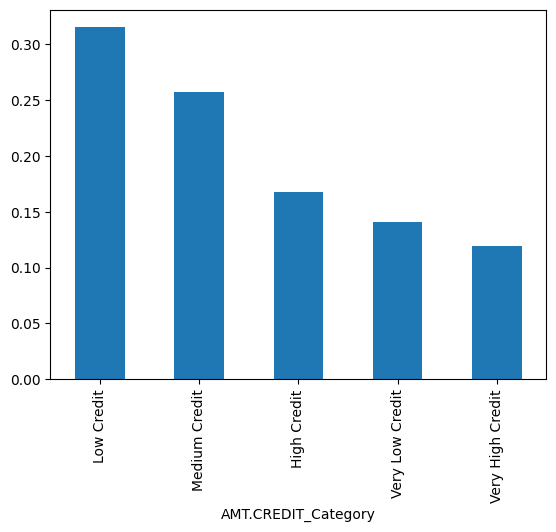

In [135]:
app_df['AMT.CREDIT_Category'].value_counts(normalize=True).plot.bar()

In [136]:
plt.show()

#### BINNING YEARS_BIRTH COLUMN

In [137]:
app_df["AGE_Category"] = pd.cut(app_df.YEARS_BIRTH, [0, 25, 45, 65, 85], labels = ["below 25", "25-45", "45-65","65-85"])

In [138]:
app_df.AGE_Category.value_counts(normalize = True)*100

AGE_Category
25-45       51.901233
45-65       41.163406
below 25     5.306477
65-85        1.628885
Name: proportion, dtype: float64

<Axes: ylabel='proportion'>

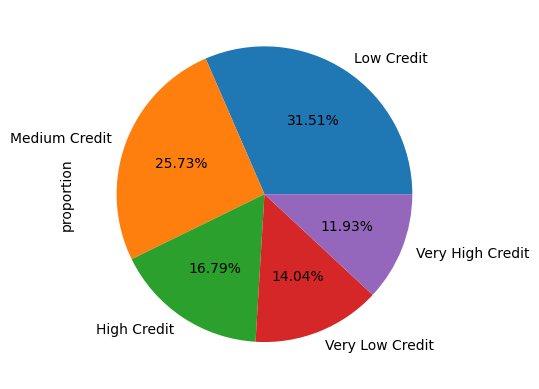

In [139]:
app_df["AMT.CREDIT_Category"].value_counts(normalize = True).plot.pie(autopct = '%.2f%%')

In [140]:
plt.show()

- CONCLUSION : Most of the applicants are between 25-45 age group

## DATA IMBALANCE CHECK

In [141]:
app_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,YEARS_BIRTH,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE,AMT.CREDIT_Category,AGE_Category
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,1.0,25,1,9,5,3,Medium Credit,below 25
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,45,3,3,0,2,NaN,25-45
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,52,0,11,6,2,Very Low Credit,45-65
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,52,8,26,6,1,Low Credit,45-65
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,54,8,11,9,3,Medium Credit,45-65


### DIVIDING DATASET WITH TARGET VARIABLE AS 0 AND 1

In [142]:
tar_0 = app_df[app_df.TARGET == 0]
tar_1 = app_df[app_df.TARGET == 1]

In [143]:
app_df.TARGET.value_counts(normalize = True)*100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

- CONCLUSION : 1 out of 9/10 applicants are defaults

## UNIVARIATE ANALYSIS

In [144]:
cat_cols = list(app_df.columns[app_df.dtypes == object])  
num_cols = list(app_df.columns[app_df.dtypes == np.int64]) + list(app_df.columns[app_df.dtypes == np.float64]) 

In [145]:
cat_cols

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE']

- Conclusion >> Insights on below columns

1. NAME_CONTRACT_TYPE - More applications are for Cash loans than Revolving loans.
2. CODE_GENDER - Number of female applicants is twice that of male applicants.
3. FLAG_OWN_CAR - 70% of applicants do not own a car.
4. FLAG_OWN_REALTY - 70% of applicants do not own a house.
5. NAME_TYPE_SUITE - 81% of applicants are Unaccompanied.
6. NAME_INCOME_TYPE - 51% of applicants earn income from Work.
7. NAME_EDUCATION_TYPE - 71% have completed Secondary / secondary special education.
8. NAME_FAMILY_STATUS - 63% are married.
9. NAME_HOUSING_TYPE - 88% live in House/apartment types.
10. OCCUPATION_TYPE - 31% have 'Other' occupation type.
11. WEEKDAY_APPR_PROCESS_START - Most applicants applied on Tuesday.
12. ORGANIZATION_TYPE - Most work for Business Entity Type 3.

### PLOT ON NUM


In [146]:
num_cols_withoutflag = []
num_cols_withflag = []
for cols in num_cols:
    if cols.startswith("FLAG"):
        num_cols_withflag.append(cols)
    else:
        num_cols_withoutflag.append(cols)


In [147]:
num_cols_withflag

['FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_3',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_5',
 'FLAG_DOCUMENT_6',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_8',
 'FLAG_DOCUMENT_9',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_13',
 'FLAG_DOCUMENT_14',
 'FLAG_DOCUMENT_15',
 'FLAG_DOCUMENT_16',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_18',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20',
 'FLAG_DOCUMENT_21']

In [148]:
num_cols_withoutflag

['SK_ID_CURR',
 'TARGET',
 'CNT_CHILDREN',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_ID_PUBLISH',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'YEARS_BIRTH',
 'YEARS_EMPLOYED',
 'YEARS_REGISTRATION',
 'YEARS_ID_PUBLISH',
 'YEARS_LAST_PHONE_CHANGE',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_REGISTRATION',
 'CNT_FAM_MEMBERS',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'OBS_30_CNT_SOCIAL_CIRCLE',
 'DEF_30_CNT_SOCIAL_CIRCLE',
 'OBS_60_CNT_SOCIAL_CIRCLE',
 'DEF_60_CNT_SOCIAL_CIRCLE',
 'DAYS_LAST_PHONE_CHANGE',
 'AMT_REQ_CREDIT_BUREAU_HOUR',
 'AMT_REQ_CREDIT_BUREAU_DAY',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'AMT_REQ_CREDIT_BUREAU_MON',
 'AMT_REQ_CREDIT_BUREAU_QRT',
 'AMT_REQ_CREDIT_BUREAU_YEAR']

count    307511.000000
mean     278180.518577
std      102790.175348
min      100002.000000
25%      189145.500000
50%      278202.000000
75%      367142.500000
max      456255.000000
Name: SK_ID_CURR, dtype: float64


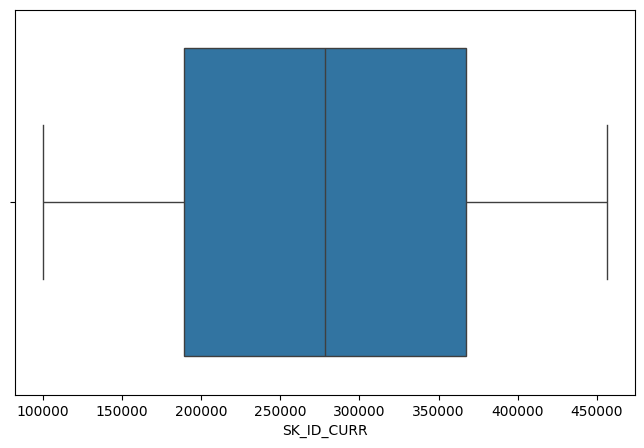

count    307511.000000
mean          0.080729
std           0.272419
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: TARGET, dtype: float64


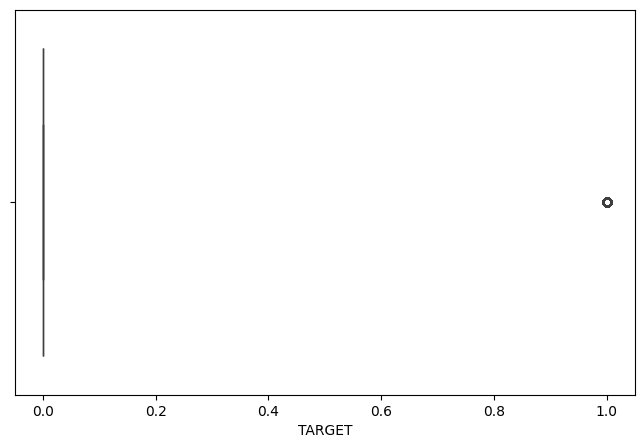

count    307511.000000
mean          0.417052
std           0.722121
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          19.000000
Name: CNT_CHILDREN, dtype: float64


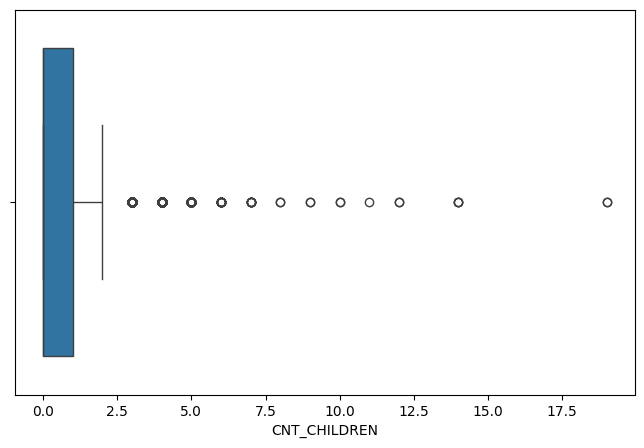

count    307511.000000
mean      16036.995067
std        4363.988632
min        7489.000000
25%       12413.000000
50%       15750.000000
75%       19682.000000
max       25229.000000
Name: DAYS_BIRTH, dtype: float64


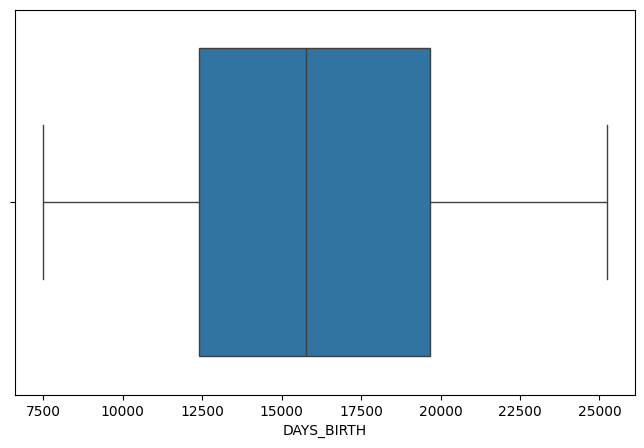

count    307511.000000
mean      67724.742149
std      139443.751806
min           0.000000
25%         933.000000
50%        2219.000000
75%        5707.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64


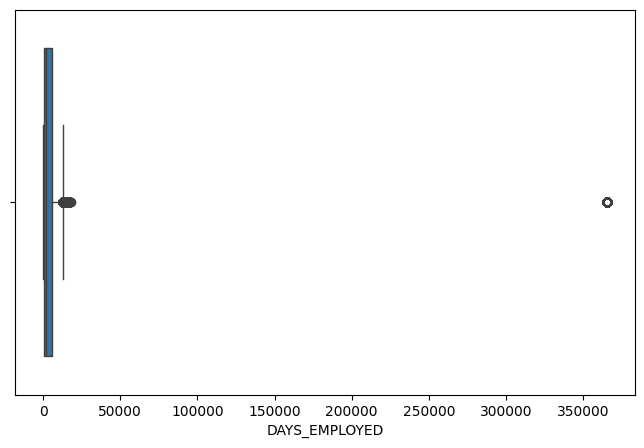

count    307511.000000
mean       2994.202373
std        1509.450419
min           0.000000
25%        1720.000000
50%        3254.000000
75%        4299.000000
max        7197.000000
Name: DAYS_ID_PUBLISH, dtype: float64


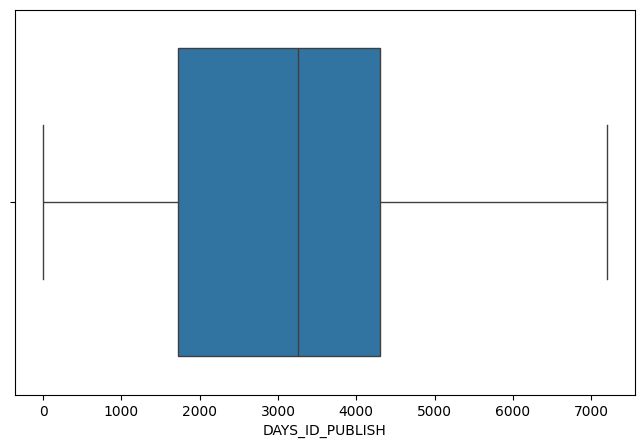

count    307511.000000
mean          2.052463
std           0.509034
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           3.000000
Name: REGION_RATING_CLIENT, dtype: float64


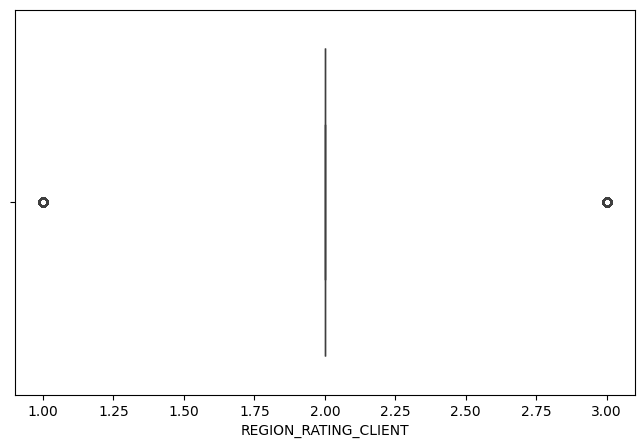

count    307511.000000
mean          2.031521
std           0.502737
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           3.000000
Name: REGION_RATING_CLIENT_W_CITY, dtype: float64


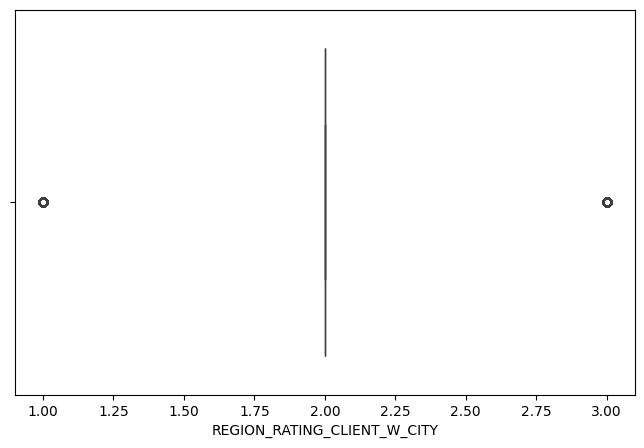

count    307511.000000
mean         12.063419
std           3.265832
min           0.000000
25%          10.000000
50%          12.000000
75%          14.000000
max          23.000000
Name: HOUR_APPR_PROCESS_START, dtype: float64


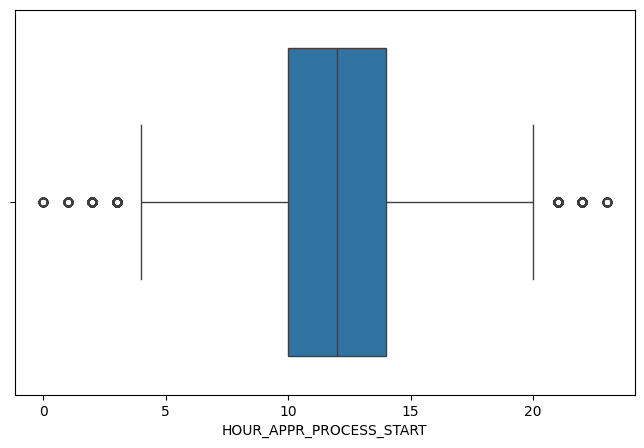

count    307511.000000
mean          0.015144
std           0.122126
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: REG_REGION_NOT_LIVE_REGION, dtype: float64


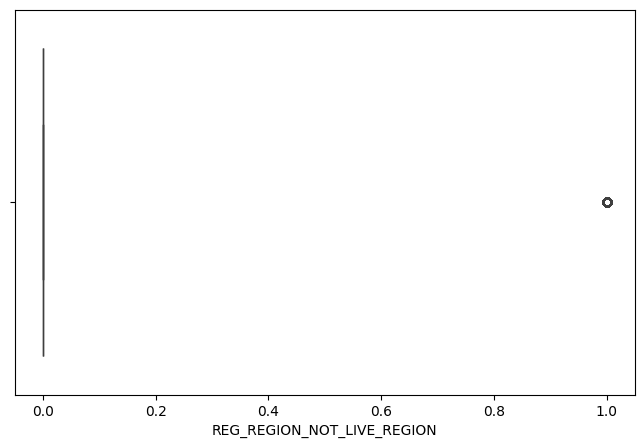

count    307511.000000
mean          0.050769
std           0.219526
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: REG_REGION_NOT_WORK_REGION, dtype: float64


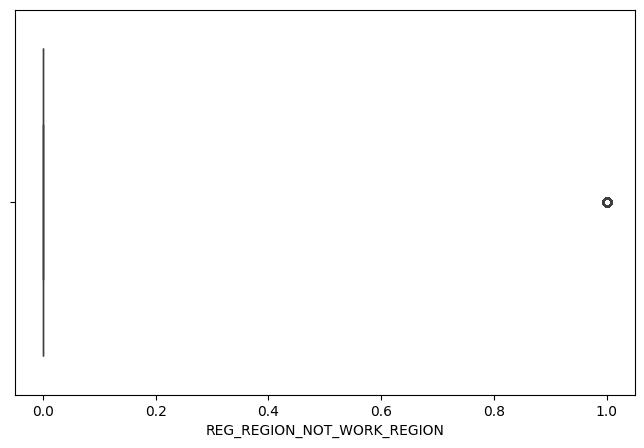

count    307511.000000
mean          0.040659
std           0.197499
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: LIVE_REGION_NOT_WORK_REGION, dtype: float64


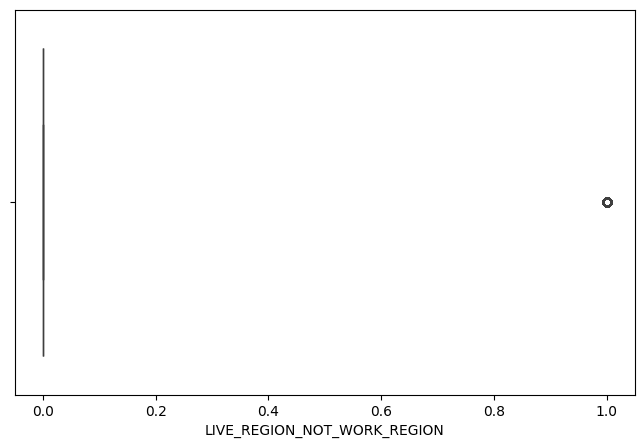

count    307511.000000
mean          0.078173
std           0.268444
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: REG_CITY_NOT_LIVE_CITY, dtype: float64


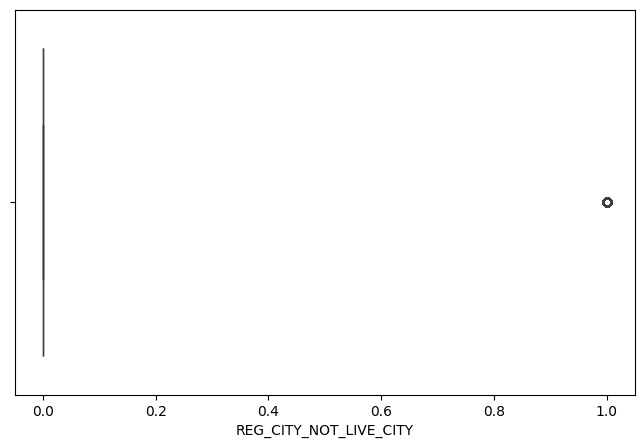

count    307511.000000
mean          0.230454
std           0.421124
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: REG_CITY_NOT_WORK_CITY, dtype: float64


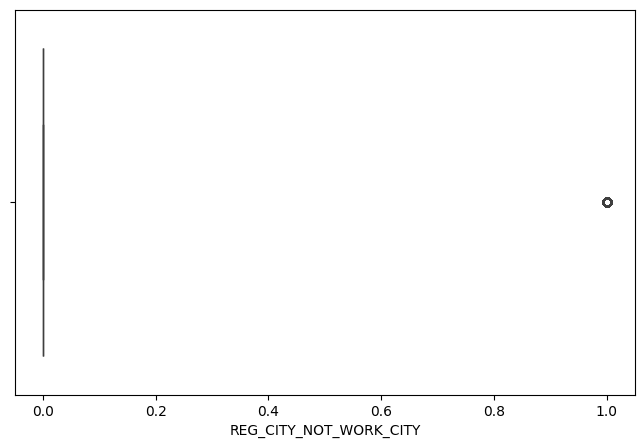

count    307511.000000
mean          0.179555
std           0.383817
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: LIVE_CITY_NOT_WORK_CITY, dtype: float64


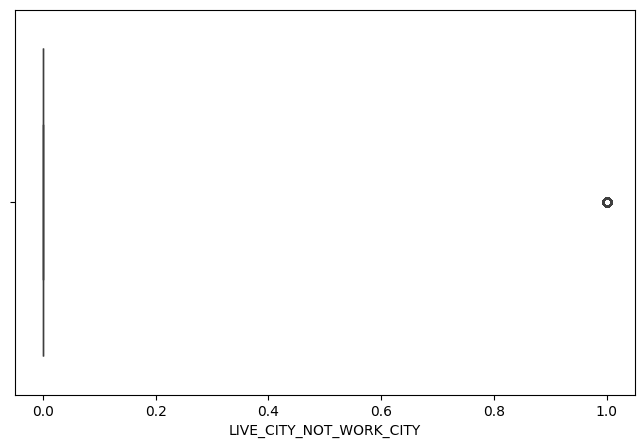

count    307511.000000
mean         43.435968
std          11.954593
min          20.000000
25%          34.000000
50%          43.000000
75%          53.000000
max          69.000000
Name: YEARS_BIRTH, dtype: float64


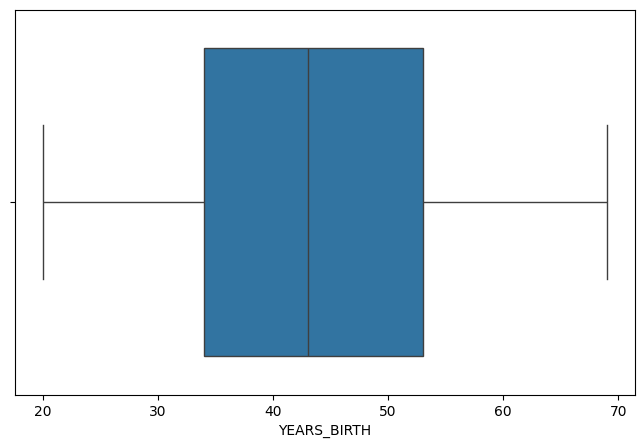

count    307511.000000
mean        185.021521
std         381.972190
min           0.000000
25%           2.000000
50%           6.000000
75%          15.000000
max        1000.000000
Name: YEARS_EMPLOYED, dtype: float64


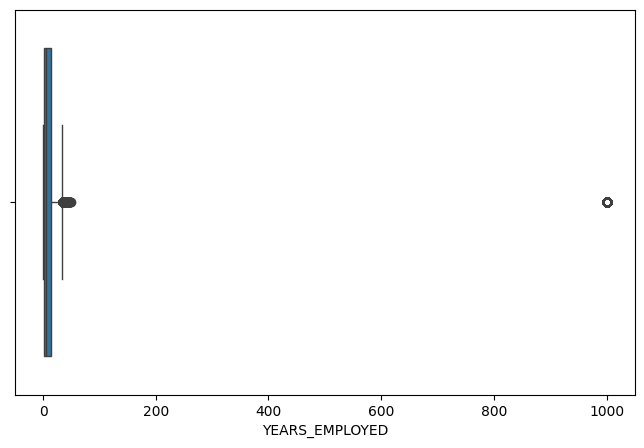

count    307511.000000
mean         13.168683
std           9.646841
min           0.000000
25%           5.000000
50%          12.000000
75%          20.000000
max          67.000000
Name: YEARS_REGISTRATION, dtype: float64


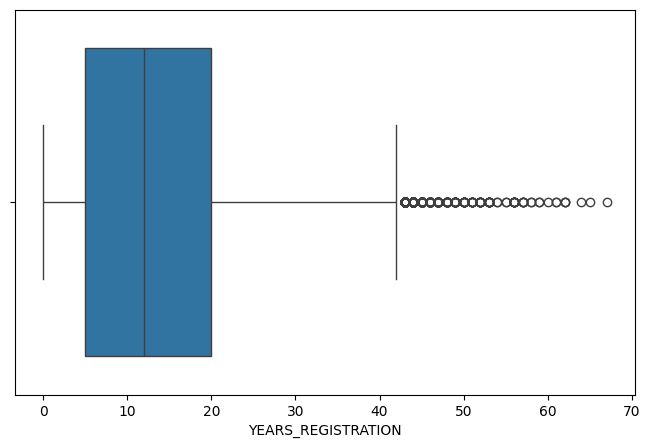

count    307511.000000
mean          7.713474
std           4.134515
min           0.000000
25%           4.000000
50%           8.000000
75%          11.000000
max          19.000000
Name: YEARS_ID_PUBLISH, dtype: float64


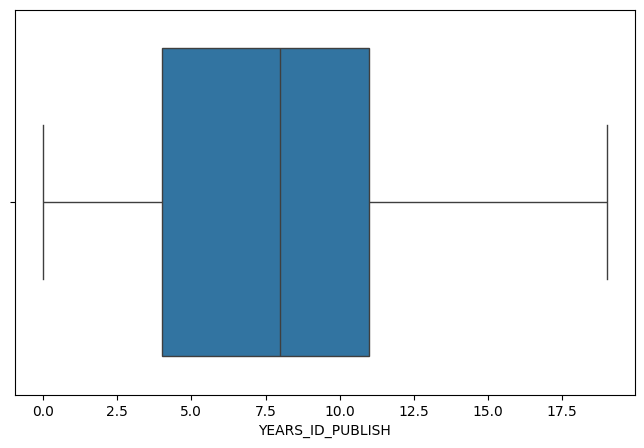

count    307511.000000
mean          2.225114
std           2.193674
min           0.000000
25%           0.000000
50%           2.000000
75%           4.000000
max          11.000000
Name: YEARS_LAST_PHONE_CHANGE, dtype: float64


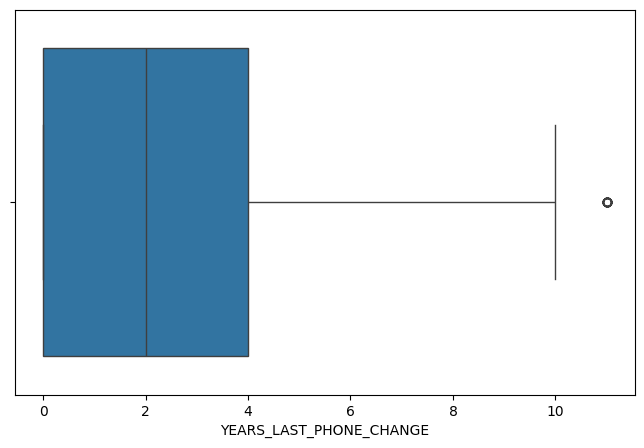

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64


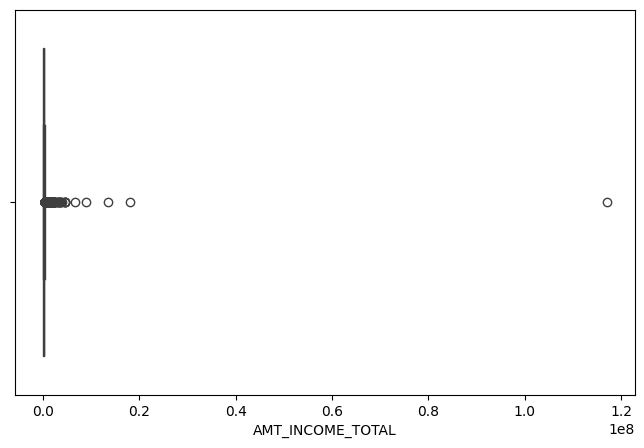

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64


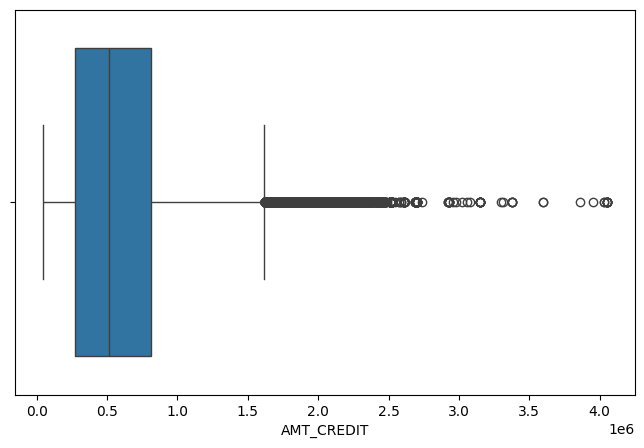

count    307511.000000
mean      27108.487841
std       14493.461065
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64


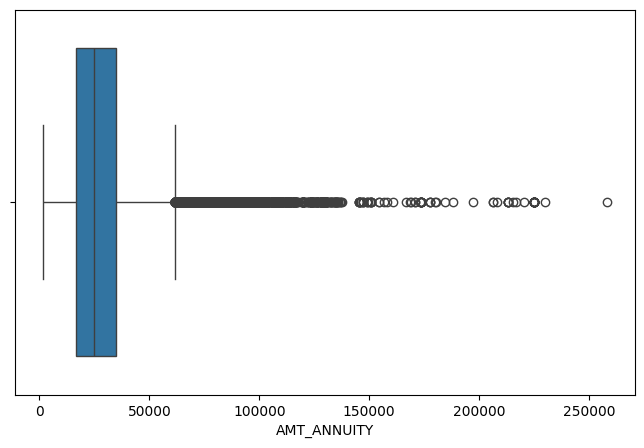

count    3.075110e+05
mean     5.383163e+05
std      3.692890e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64


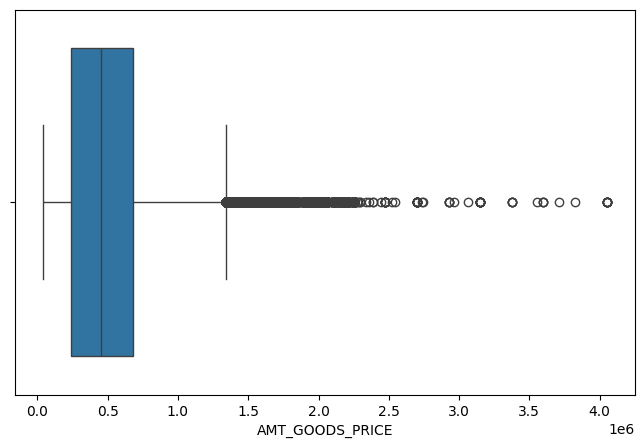

count    307511.000000
mean          0.020868
std           0.013831
min           0.000290
25%           0.010006
50%           0.018850
75%           0.028663
max           0.072508
Name: REGION_POPULATION_RELATIVE, dtype: float64


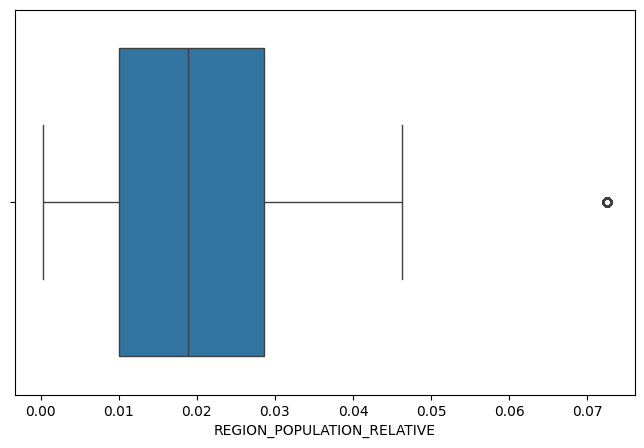

count    307511.000000
mean       4986.120328
std        3522.886321
min           0.000000
25%        2010.000000
50%        4504.000000
75%        7479.500000
max       24672.000000
Name: DAYS_REGISTRATION, dtype: float64


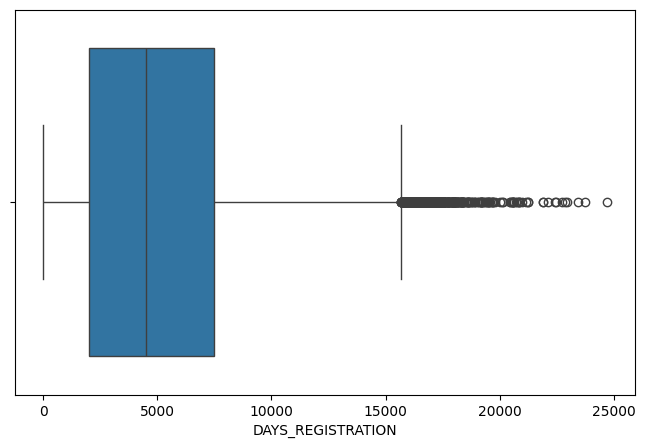

count    307511.000000
mean          2.152664
std           0.910679
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          20.000000
Name: CNT_FAM_MEMBERS, dtype: float64


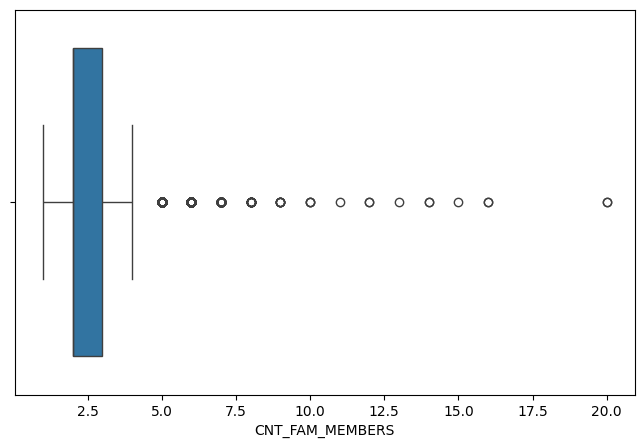

count    3.075110e+05
mean     5.145034e-01
std      1.908699e-01
min      8.173617e-08
25%      3.929737e-01
50%      5.659614e-01
75%      6.634218e-01
max      8.549997e-01
Name: EXT_SOURCE_2, dtype: float64


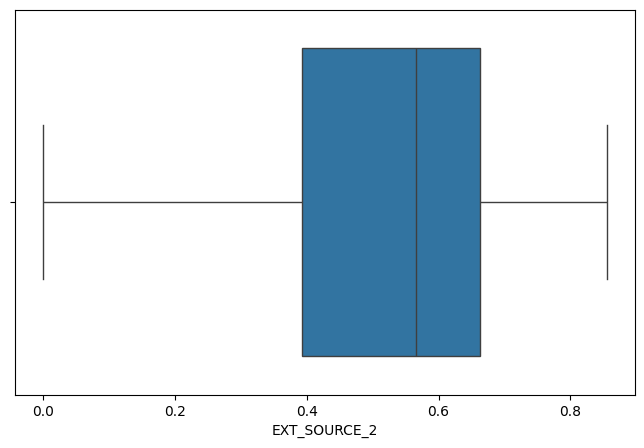

count    307511.000000
mean          0.515695
std           0.174736
min           0.000527
25%           0.417100
50%           0.535276
75%           0.636376
max           0.896010
Name: EXT_SOURCE_3, dtype: float64


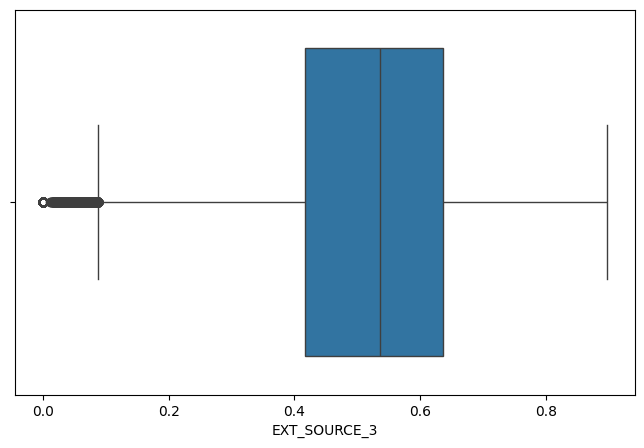

count    307511.000000
mean          1.417523
std           2.398395
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max         348.000000
Name: OBS_30_CNT_SOCIAL_CIRCLE, dtype: float64


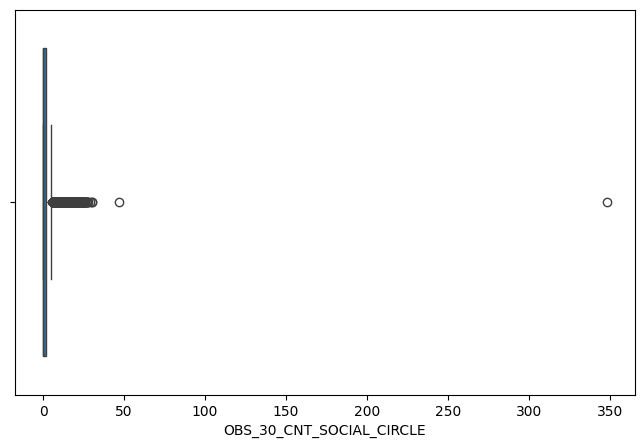

count    307511.000000
mean          0.142944
std           0.446033
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          34.000000
Name: DEF_30_CNT_SOCIAL_CIRCLE, dtype: float64


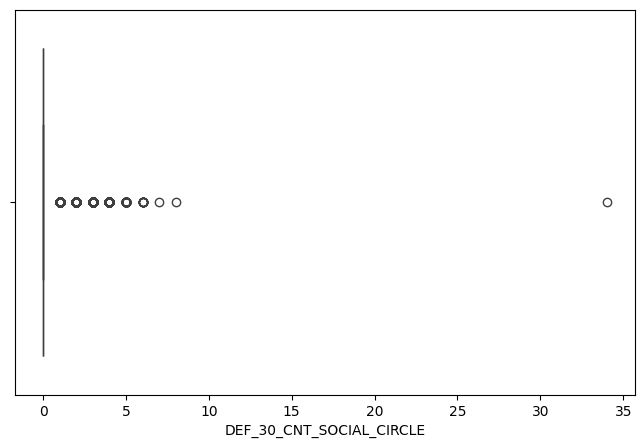

count    307511.000000
mean          1.400626
std           2.377224
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max         344.000000
Name: OBS_60_CNT_SOCIAL_CIRCLE, dtype: float64


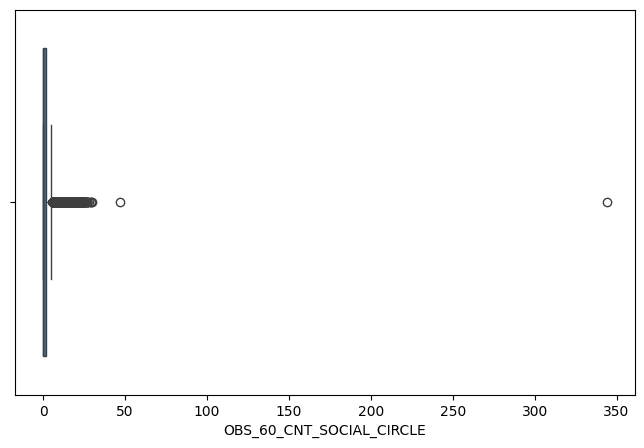

count    307511.000000
mean          0.099717
std           0.361735
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          24.000000
Name: DEF_60_CNT_SOCIAL_CIRCLE, dtype: float64


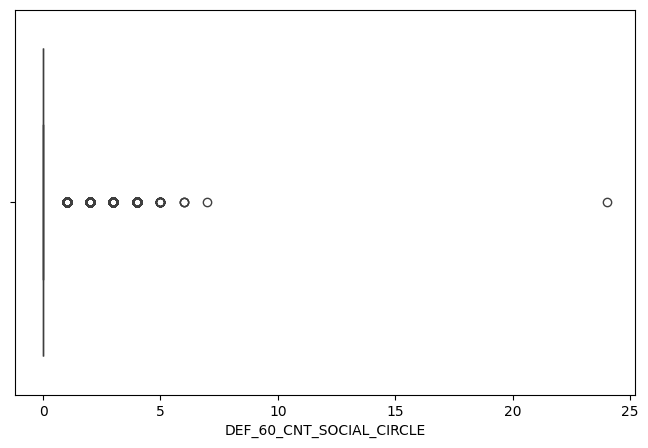

count    307511.000000
mean        962.858119
std         826.807226
min           0.000000
25%         274.000000
50%         757.000000
75%        1570.000000
max        4292.000000
Name: DAYS_LAST_PHONE_CHANGE, dtype: float64


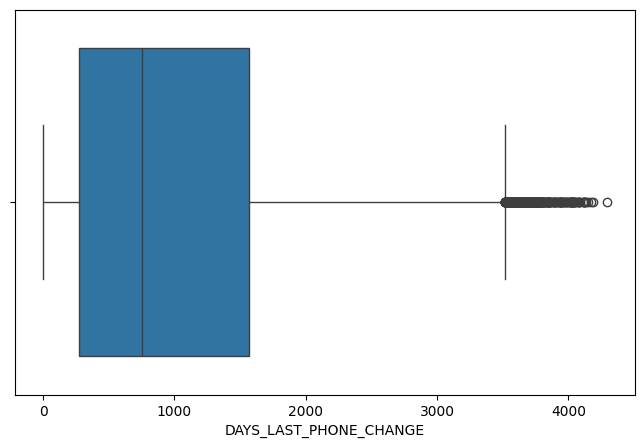

count    307511.000000
mean          0.005538
std           0.078014
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           4.000000
Name: AMT_REQ_CREDIT_BUREAU_HOUR, dtype: float64


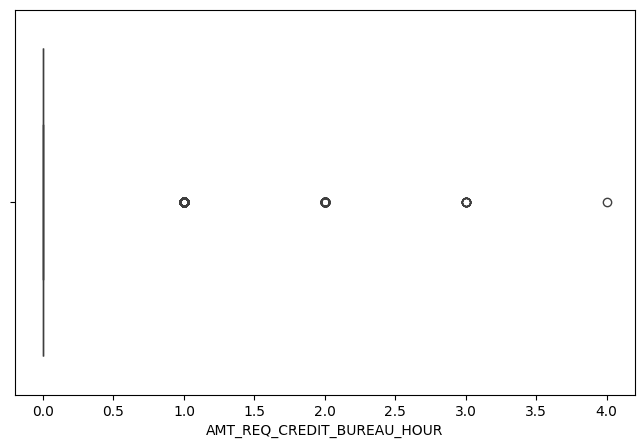

count    307511.000000
mean          0.006055
std           0.103037
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           9.000000
Name: AMT_REQ_CREDIT_BUREAU_DAY, dtype: float64


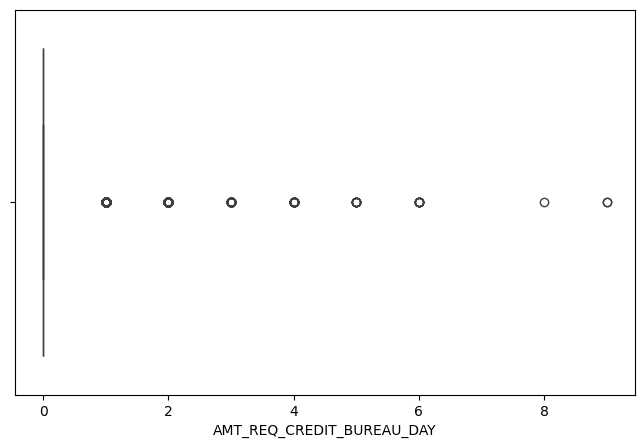

count    307511.000000
mean          0.029723
std           0.190728
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           8.000000
Name: AMT_REQ_CREDIT_BUREAU_WEEK, dtype: float64


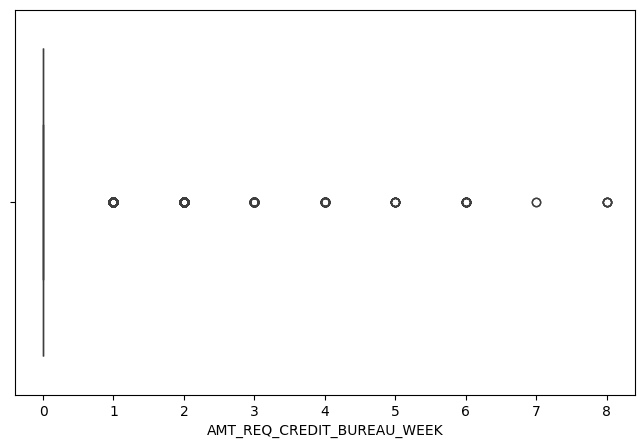

count    307511.000000
mean          0.231293
std           0.856810
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          27.000000
Name: AMT_REQ_CREDIT_BUREAU_MON, dtype: float64


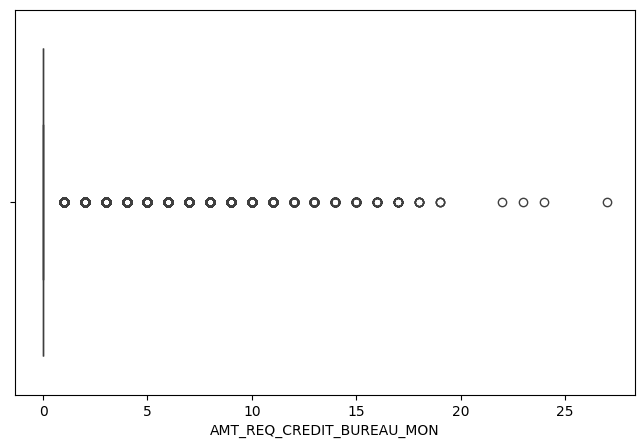

count    307511.000000
mean          0.229631
std           0.744059
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         261.000000
Name: AMT_REQ_CREDIT_BUREAU_QRT, dtype: float64


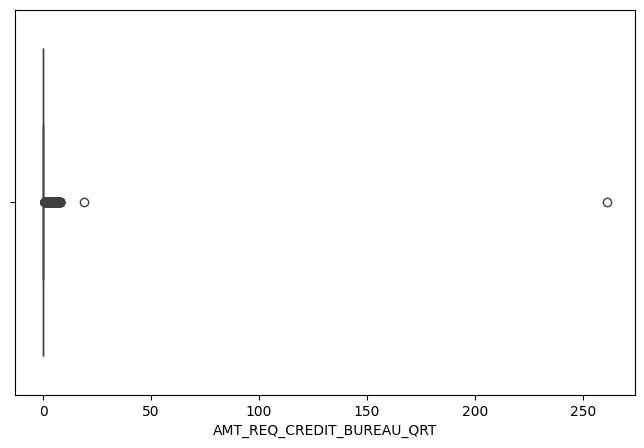

count    307511.000000
mean          1.643447
std           1.855821
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max          25.000000
Name: AMT_REQ_CREDIT_BUREAU_YEAR, dtype: float64


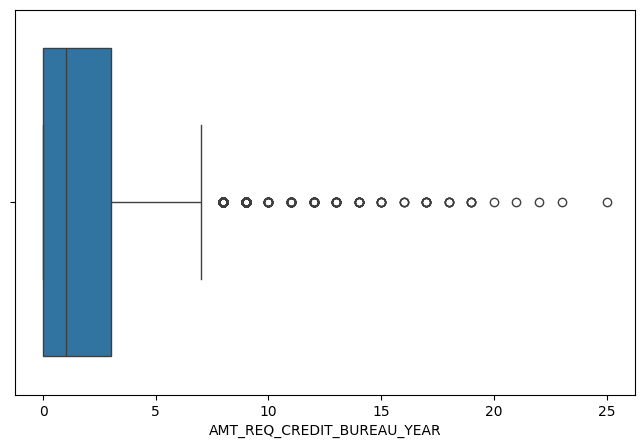

In [149]:
for cols in num_cols_withoutflag:
    print(app_df[cols].describe())
    plt.figure(figsize = [8,5])
    sns.boxplot(data=app_df, x=cols)
    plt.show()

In [150]:
# Duplicate loop removed — univariate analysis with TARGET split is below


### UNIVARIATE ANALYSIS ON COLUMNS WITH TARGET 0 AND 1

Plot on NAME_CONTRACT_TYPE for Target 0 and 1


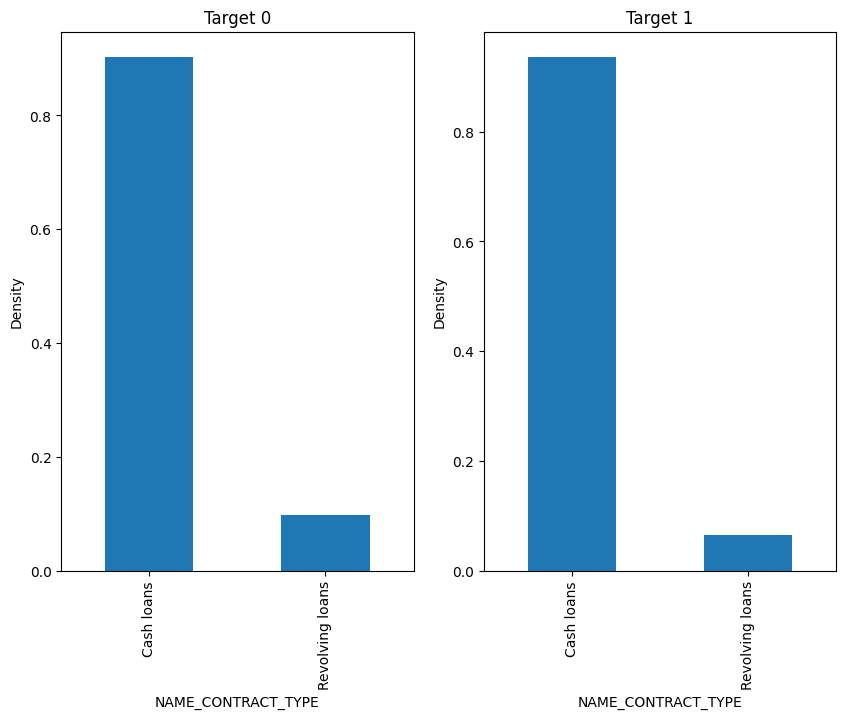




Plot on CODE_GENDER for Target 0 and 1


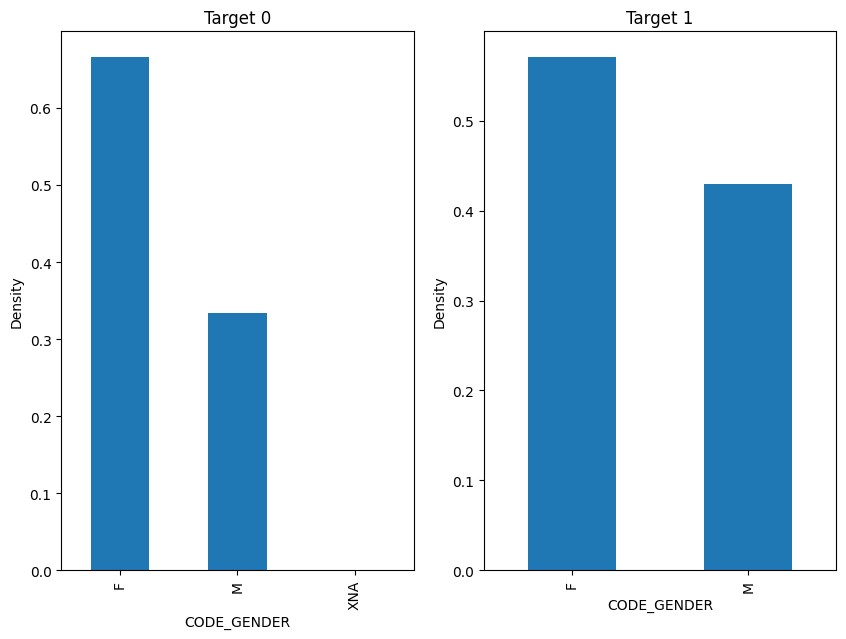




Plot on FLAG_OWN_CAR for Target 0 and 1


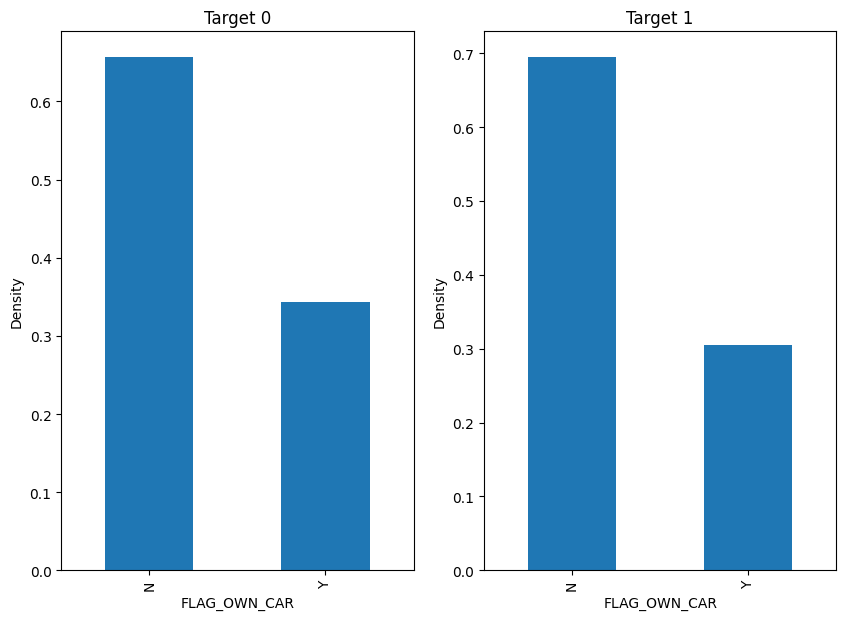




Plot on FLAG_OWN_REALTY for Target 0 and 1


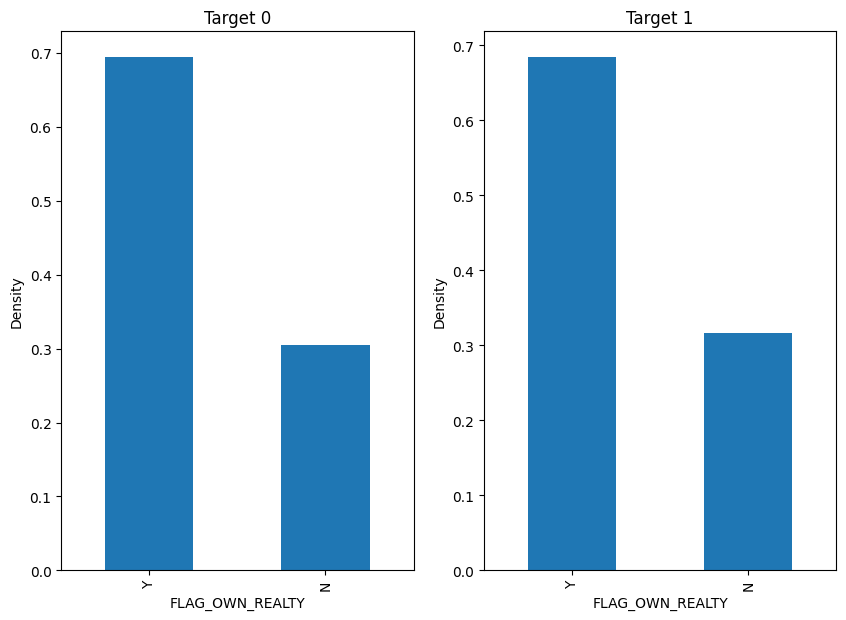




Plot on NAME_TYPE_SUITE for Target 0 and 1


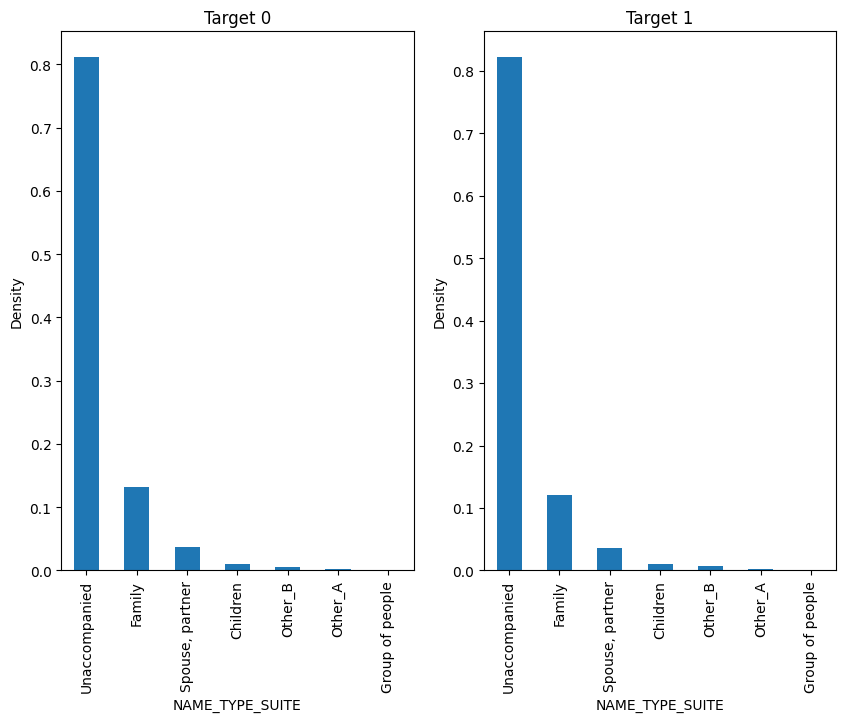




Plot on NAME_INCOME_TYPE for Target 0 and 1


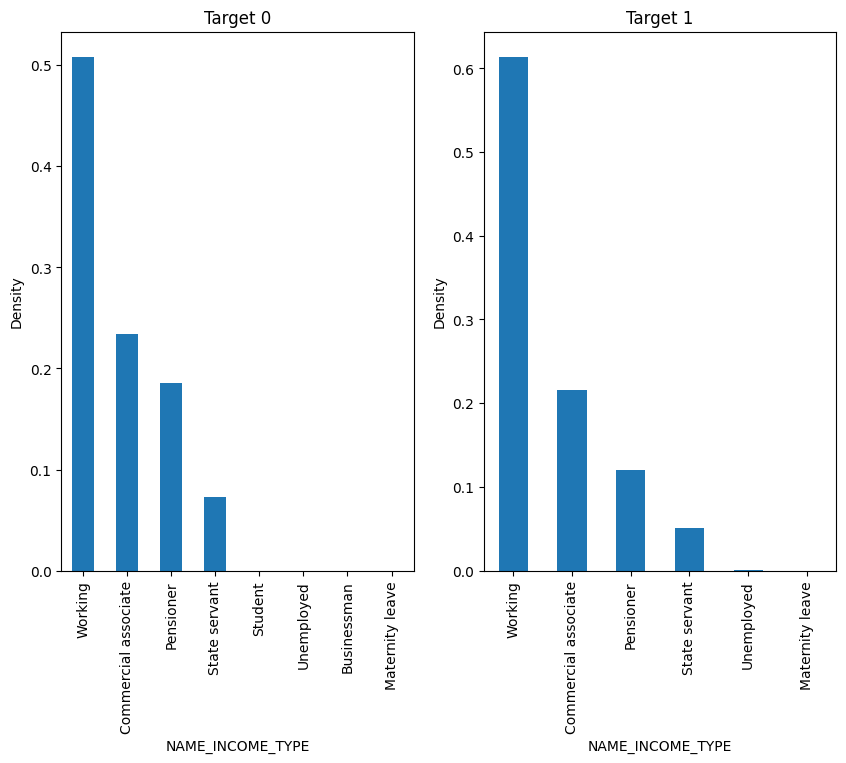




Plot on NAME_EDUCATION_TYPE for Target 0 and 1


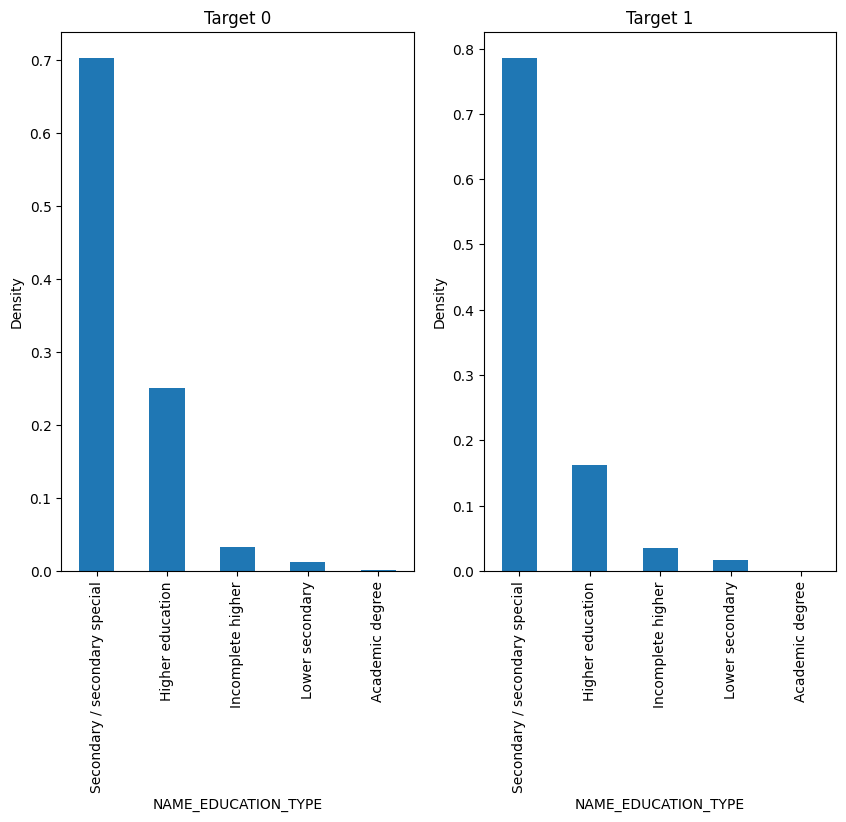




Plot on NAME_FAMILY_STATUS for Target 0 and 1


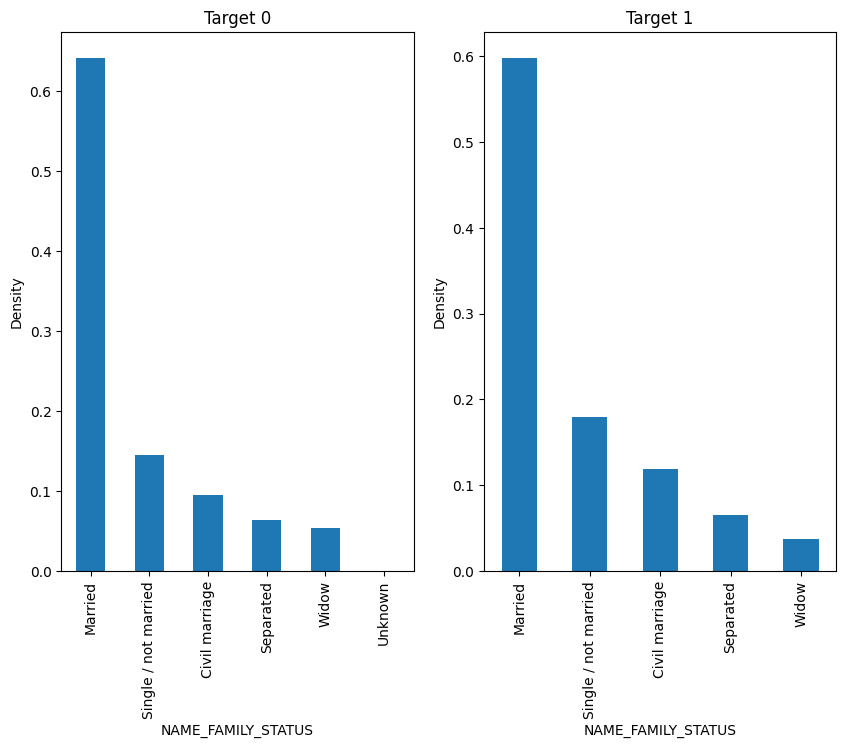




Plot on NAME_HOUSING_TYPE for Target 0 and 1


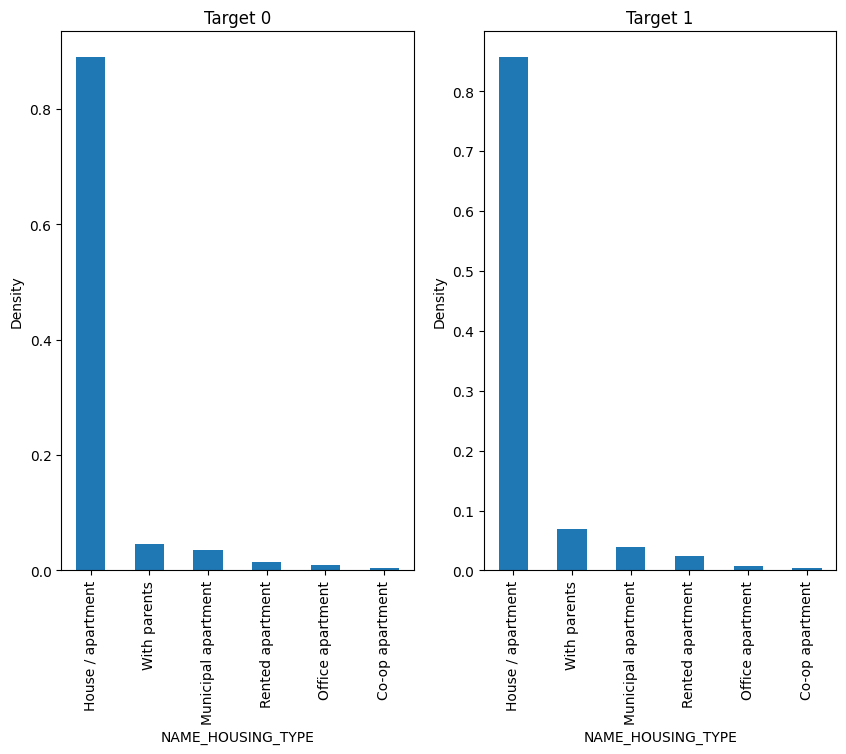




Plot on OCCUPATION_TYPE for Target 0 and 1


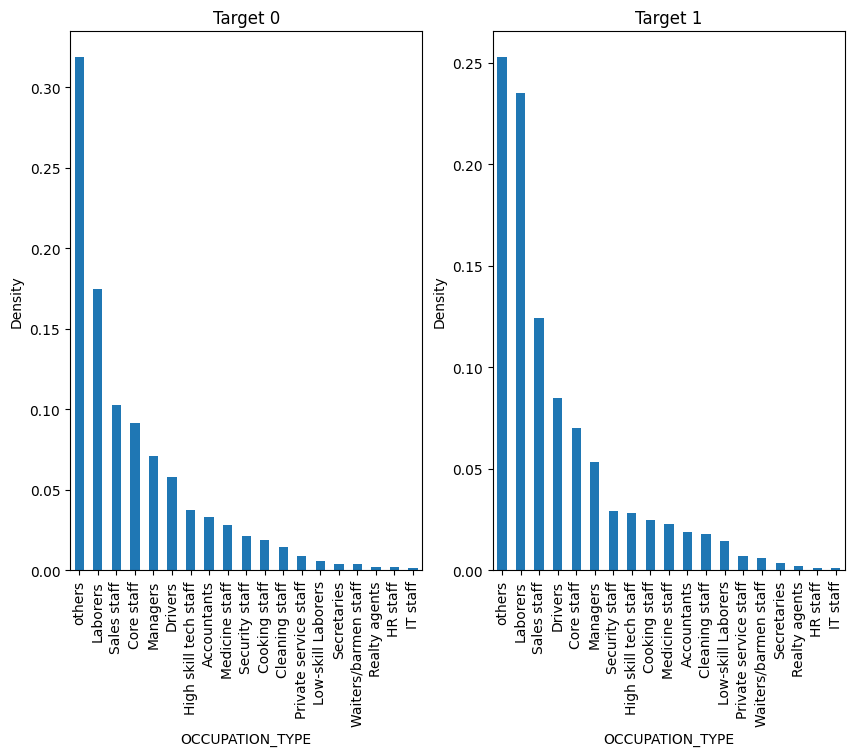




Plot on WEEKDAY_APPR_PROCESS_START for Target 0 and 1


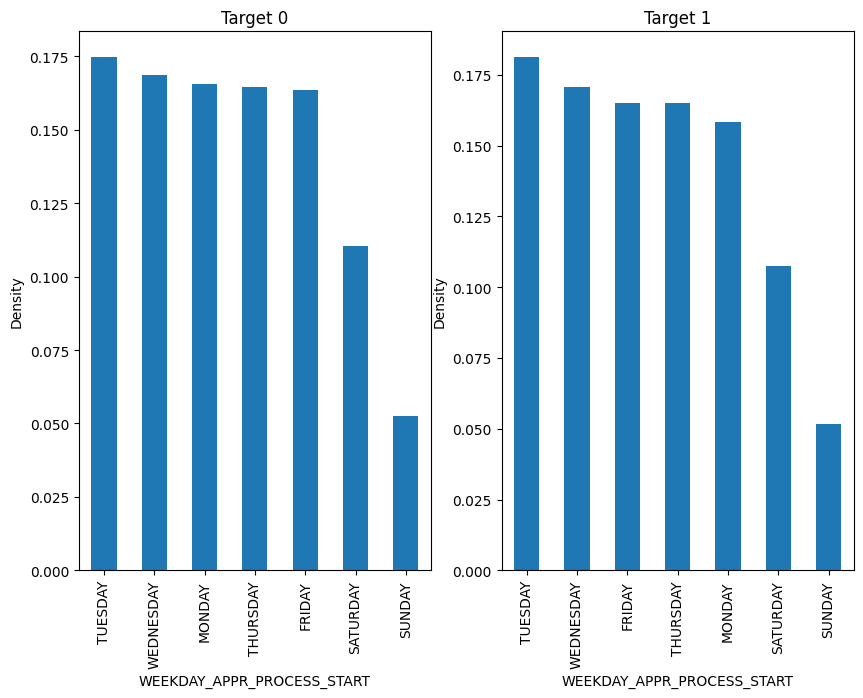




Plot on ORGANIZATION_TYPE for Target 0 and 1


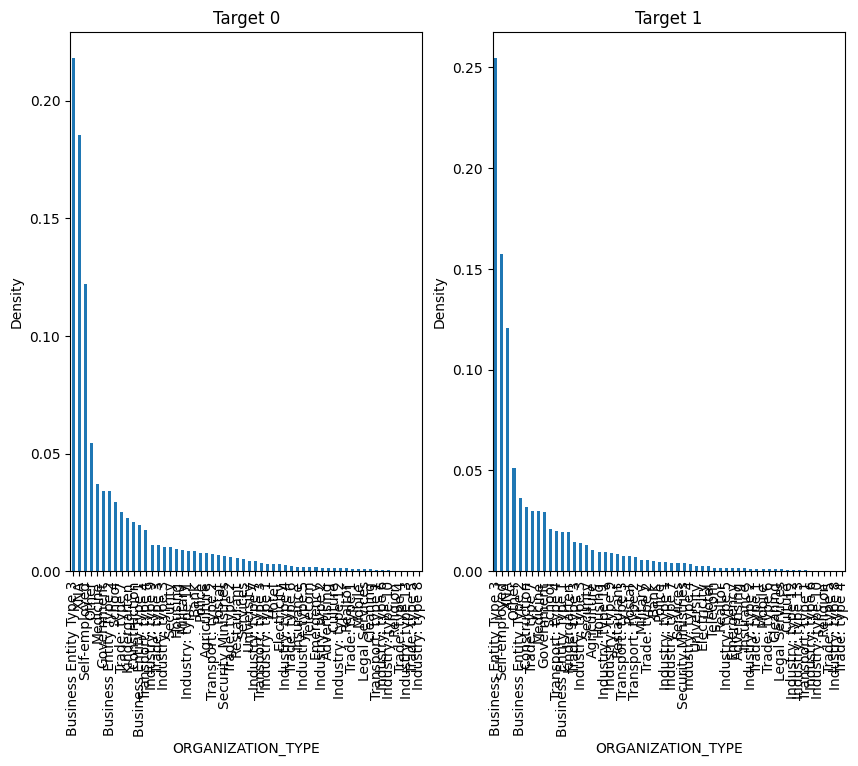

In [151]:
for col in cat_cols:
    print(f"Plot on {col} for Target 0 and 1")
    plt.figure(figsize=[10,7])
    plt.subplot(1,2,1)
    tar_0[col].value_counts(normalize=True).plot.bar()
    plt.title("Target 0")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.subplot(1,2,2)
    tar_1[col].value_counts(normalize=True).plot.bar()
    plt.title("Target 1")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()
    print("\n\n")


CONCLUSION 
- NAME_CONTRACT_TYPE: More applicants receive Cash loans than Revolving loans (both Target 0 and 1)
- CODE_GENDER: Female applicants are twice as many as male applicants (both Target 0 and 1)
- FLAG_OWN_CAR: Around 70% do not own a car (both Target 0 and 1)
- FLAG_OWN_REALTY: Around 70% do not own real estate (both Target 0 and 1)
- NAME_TYPE_SUITE: 81% are unaccompanied applicants (both Target 0 and 1)
- NAME_INCOME_TYPE: Most (51%) earn income from Work (both Target 0 and 1)
- NAME_EDUCATION_TYPE: 71% have Secondary / Secondary special education (both Target 0 and 1)
- NAME_FAMILY_STATUS: 63% are married (both Target 0 and 1)
- NAME_HOUSING_TYPE: 88% live in House/Apartment (both Target 0 and 1)
- OCCUPATION_TYPE: Most (31%) are in ‘Other’; non-defaulters common, while Laborers, Sales staff, Drivers, Core staff struggle with repayment
- WEEKDAY_APPR_PROCESS_START: Most applications on Tuesday, fewest on Sunday
- ORGANIZATION_TYPE: Most applicants from ‘Business Entity Type 3’, ‘Self Employed’, and ‘Other’


### ANALYSIS ON AMT_GOODS_PRICE ON TARGET 0 AND 1

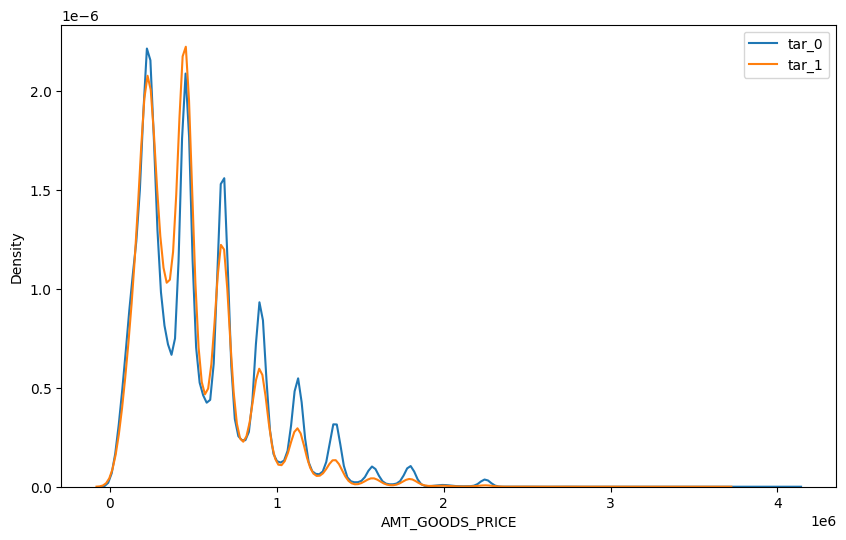

In [152]:
plt.figure(figsize = (10,6))
sns.distplot(tar_0["AMT_GOODS_PRICE"], label = "tar_0", hist = False)
sns.distplot(tar_1["AMT_GOODS_PRICE"], label = "tar_1", hist = False)
plt.legend()
plt.show()


CONCLUSION : The price of the goods for which loan is given has the same variation for target 0 and 1

## BIVARIATE AND MULTIVARIATE ANALYSIS

### BIVARIATE ANALYSIS BETWEEN WEEKDAY_APPR_PROCESS_START VS HOUR_APPR_PROCESS_START

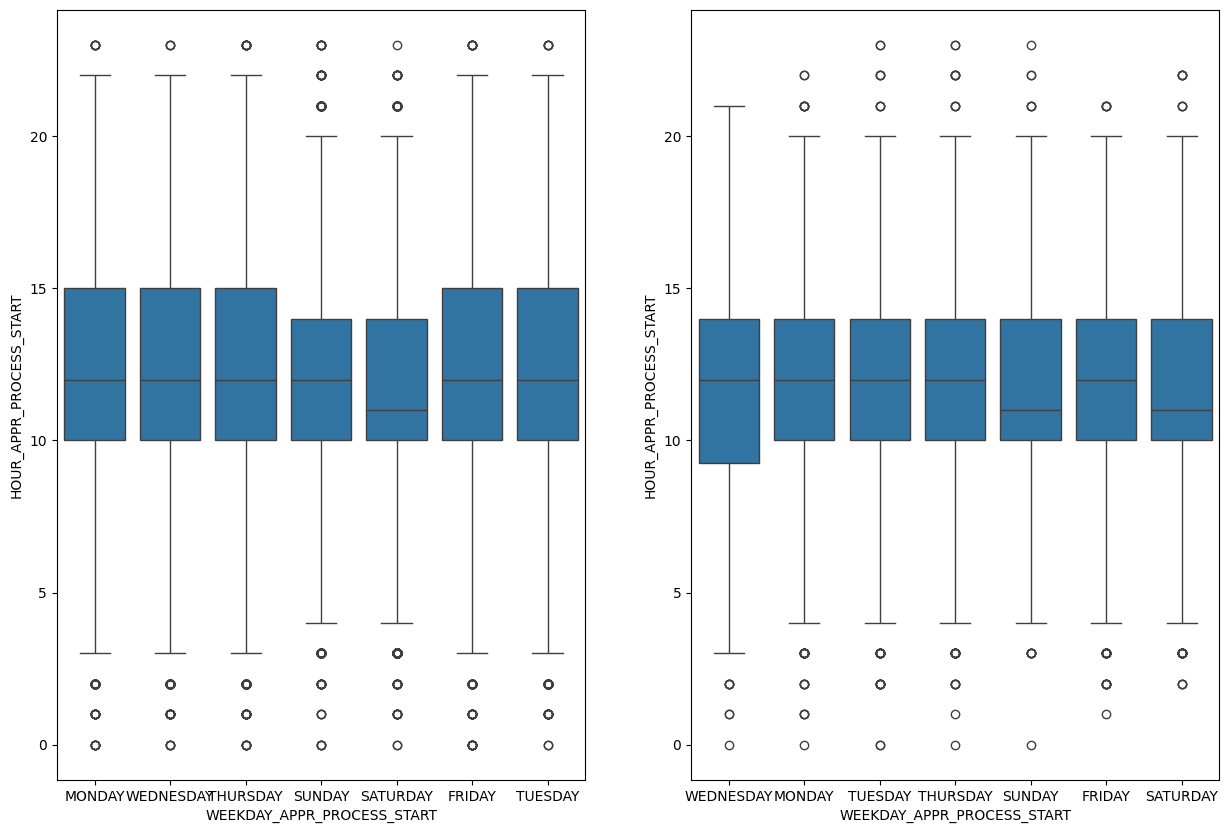

In [153]:
plt.figure(figsize = (15,10))
plt.subplot(1,2,1)
sns.boxplot(x="WEEKDAY_APPR_PROCESS_START", y="HOUR_APPR_PROCESS_START", data=tar_0)
plt.subplot(1,2,2)
sns.boxplot(x="WEEKDAY_APPR_PROCESS_START", y="HOUR_APPR_PROCESS_START", data=tar_1)
plt.show()

Conclusion >>
- The Bank operates between 10am to 3pm except for Saturday and Sunday, when it's open from 10am to 2pm.
- Around 11:30am to 12pm, about 50% of customers visit the branch for loan applications on all days, except Saturday, where peak time is 10am to 11am for both Target 0 and 1.
- Loan defaulters have typically applied between 9:30am–10am and 2pm, whereas applicants who repay loans on time generally applied between 10am and 3pm.


### BIVARIATE ANALYSIS BETWEEN AGE_CATEGORY VS AMT_CREDIT

Conclusion >>
- The applicants between age group 25 to 65 have Credit amount of the loan less than 2,500,000 and are able to repay the loan properly.
- The applicants with less than 100,000 Credit amount are with age group greater than 65 may be considered as loan defaulters.
- Most applicants who have Credit amount of the loan less than 1,700,000 are loan defaulters with age 25 and less.


### PAIR PLOT OF AMOUNT COLUMNS FOR TARGET 0 AND 1

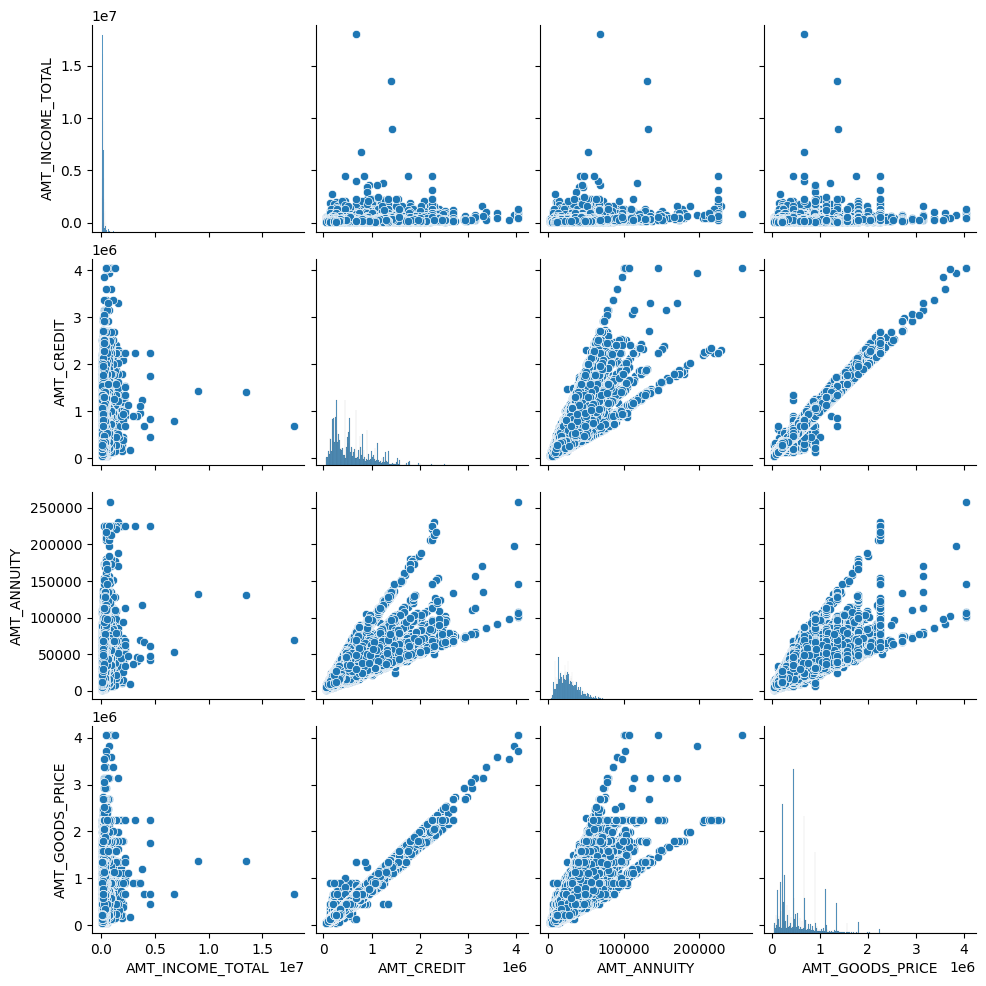

In [154]:
sns.pairplot(tar_0[["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]])
plt.show()

In [155]:
plt.show()

Conclusion : For Applicants who are able to repay the loan on time:
- AMT_CREDIT increases or varies linearly with AMT_GOODS_PRICE, and also increases with AMT_ANNUITY.
- AMT_ANNUITY increases with increases in AMT_GOODS_PRICE and AMT_CREDIT.
- AMT_GOODS_PRICE increases with increases in AMT_CREDIT and AMT_ANNUITY.
- AMT_INCOME_TOTAL shows a drastic increase with slight increases in AMT_CREDIT, AMT_ANNUITY, and AMT_GOODS_PRICE.


### PAIR PLOT OF AMOUNT COLUMNS FOR TARGET 1

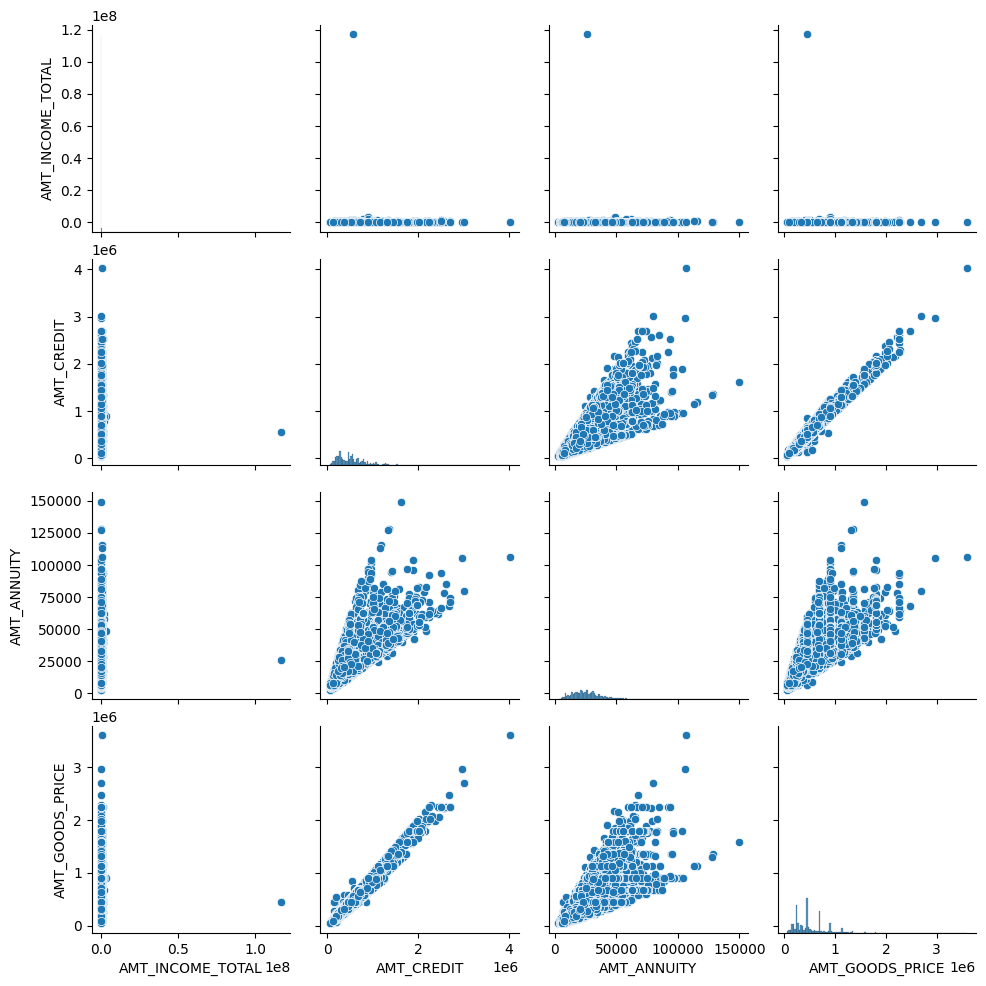

In [156]:
sns.pairplot(tar_1[["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]])
plt.show()

In [157]:
plt.show()

Conclusion → For Applicants who are unable to repay the loan on time:
- AMT_CREDIT increases or varies linearly with AMT_GOODS_PRICE, and AMT_CREDIT increases with AMT_ANNUITY.
- AMT_ANNUITY increases with increases in AMT_GOODS_PRICE and AMT_CREDIT.
- AMT_GOODS_PRICE increases with increases in AMT_CREDIT and AMT_ANNUITY.
- AMT_INCOME_TOTAL has a drastic increase with slight increases in AMT_CREDIT, AMT_ANNUITY, and AMT_GOODS_PRICE.


### CORRELATION BETWEEN NUMERICAL COLUMNS

In [158]:
corr_data = app_df[["AMT_INCOME_TOTAL","AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE", "YEARS_BIRTH", "YEARS_EMPLOYED", "YEARS_REGISTRATION", "YEARS_ID_PUBLISH", "YEARS_LAST_PHONE_CHANGE"]]


In [159]:
corr_data.head()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,YEARS_BIRTH,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE
0,202500.0,406597.5,24700.5,351000.0,25,1,9,5,3
1,270000.0,1293502.5,35698.5,1129500.0,45,3,3,0,2
2,67500.0,135000.0,6750.0,135000.0,52,0,11,6,2
3,135000.0,312682.5,29686.5,297000.0,52,8,26,6,1
4,121500.0,513000.0,21865.5,513000.0,54,8,11,9,3


In [160]:
corr_data.corr()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,YEARS_BIRTH,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE
AMT_INCOME_TOTAL,1.000000,0.156870,0.191657,0.159632,-0.027226,-0.063836,-0.027783,-0.008648,0.018592
AMT_CREDIT,0.156870,1.000000,0.770127,0.986734,0.055408,-0.064319,-0.009521,0.006831,0.077057
AMT_ANNUITY,0.191657,0.770127,1.000000,0.774837,-0.009453,-0.102853,-0.038375,-0.011100,0.064893
AMT_GOODS_PRICE,0.159632,0.986734,0.774837,1.000000,0.053484,-0.062191,-0.011456,0.009571,0.079095
YEARS_BIRTH,-0.027226,0.055408,-0.009453,0.053484,1.000000,0.623879,0.331704,0.271453,0.086527
YEARS_EMPLOYED,-0.063836,-0.064319,-0.102853,-0.062191,0.623879,1.000000,0.214592,0.274460,-0.016393
YEARS_REGISTRATION,-0.027783,-0.009521,-0.038375,-0.011456,0.331704,0.214592,1.000000,0.101373,0.058831
YEARS_ID_PUBLISH,-0.008648,0.006831,-0.011100,0.009571,0.271453,0.274460,0.101373,1.000000,0.093213
YEARS_LAST_PHONE_CHANGE,0.018592,0.077057,0.064893,0.079095,0.086527,-0.016393,0.058831,0.093213,1.000000


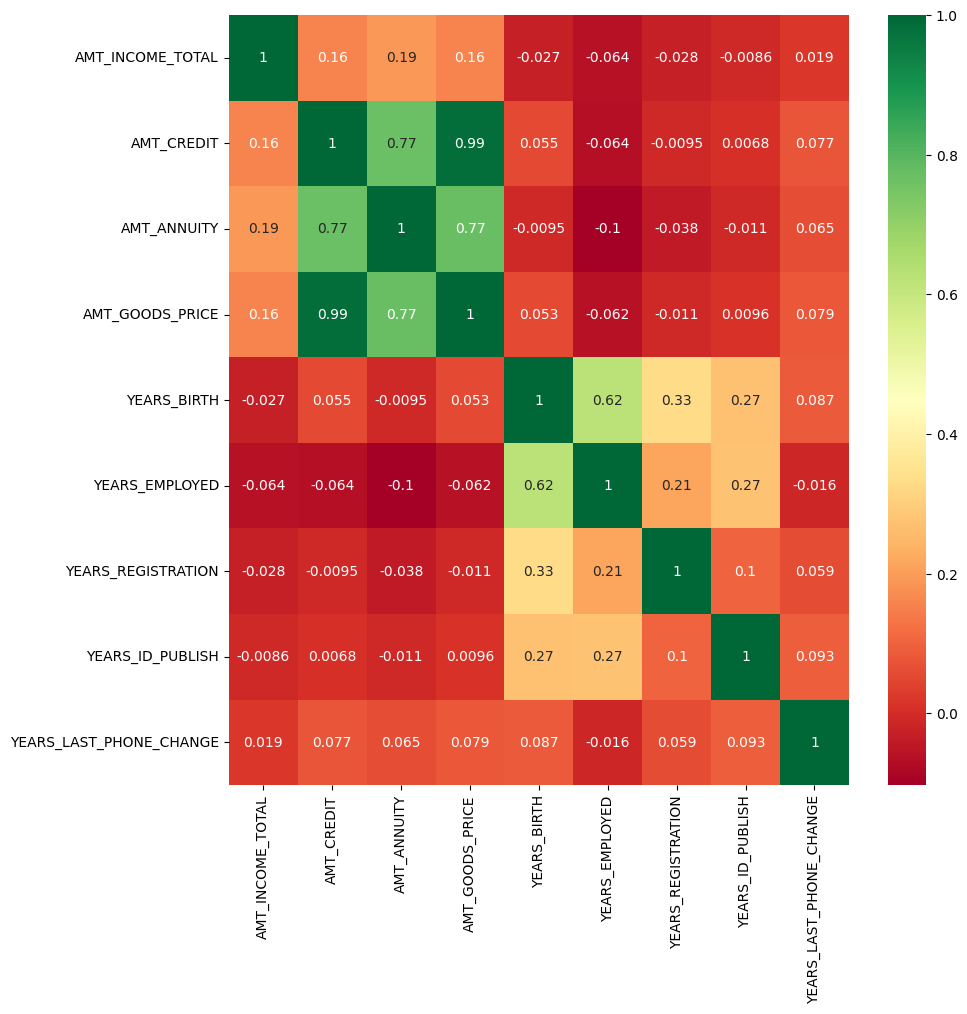

In [161]:
plt.figure(figsize = (10,10))
sns.heatmap(corr_data.corr(), annot=True, cmap="RdYlGn")
plt.show()


In [162]:
plt.show()

Conclusion → Correlation Insights:
- AMT_INCOME_TOTAL has modest positive correlations with:
 AMT_CREDIT (0.16)
AMT_ANNUITY (0.19)
AMT_GOODS_PRICE (0.16)
AMT_CREDIT correlates:
- Positively with AMT_GOODS_PRICE (0.99), AMT_ANNUITY (0.77)
- Negatively with YEARS_EMPLOYED (–0.064)
- AMT_ANNUITY:
- Positively linked with AMT_CREDIT (0.77)
- Negatively with YEARS_EMPLOYED (–0.1)
- AMT_GOODS_PRICE increases alongside AMT_CREDIT and AMT_ANNUITY
- YEARS_BIRTH shows:
- Positive correlation with YEARS_EMPLOYED and AMT_GOODS_PRICE
- Negative correlation with AMT_ANNUITY and AMT_INCOME_TOTAL
- YEARS_EMPLOYED:
- Positively tied to YEARS_REGISTRATION and YEARS_ID_PUBLISH
- Negatively to AMT_ANNUITY (–0.1)
- YEARS_REGISTRATION correlates positively with:
- YEARS_ID_PUBLISH, YEARS_BIRTH, and YEARS_EMPLOYED
- YEARS_ID_PUBLISH:
- Positively linked with YEARS_REGISTRATION
- Negatively linked with AMT_INCOME_TOTAL, AMT_ANNUITY
- YEARS_LAST_PHONE_CHANGE:
- Positively correlated with AMT_GOODS_PRICE and YEARS_ID_PUBLISH
- Negatively with YEARS_EMPLOYED


### SPLIT THE NUMERICAL VARIABLES BASED ON TARGET 0 AND 1TO FIND THE CORRELATION

In [163]:
corr_data_0 = tar_0[["AMT_INCOME_TOTAL","AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE", "YEARS_BIRTH", "YEARS_EMPLOYED", "YEARS_REGISTRATION", "YEARS_ID_PUBLISH", "YEARS_LAST_PHONE_CHANGE"]]


In [164]:
corr_data_0.head()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,YEARS_BIRTH,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE
1,270000.0,1293502.5,35698.5,1129500.0,45,3,3,0,2
2,67500.0,135000.0,6750.0,135000.0,52,0,11,6,2
3,135000.0,312682.5,29686.5,297000.0,52,8,26,6,1
4,121500.0,513000.0,21865.5,513000.0,54,8,11,9,3
5,99000.0,490495.5,27517.5,454500.0,46,4,13,1,6


In [165]:
corr_data_0.corr()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,YEARS_BIRTH,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE
AMT_INCOME_TOTAL,1.000000,0.342799,0.418948,0.349426,-0.062494,-0.140394,-0.064883,-0.022770,0.040691
AMT_CREDIT,0.342799,1.000000,0.771297,0.987022,0.047366,-0.070105,-0.013375,0.001778,0.072698
AMT_ANNUITY,0.418948,0.771297,1.000000,0.776421,-0.012251,-0.104979,-0.039303,-0.013915,0.063098
AMT_GOODS_PRICE,0.349426,0.987022,0.776421,1.000000,0.044637,-0.068527,-0.015806,0.004011,0.073970
YEARS_BIRTH,-0.062494,0.047366,-0.012251,0.044637,1.000000,0.626028,0.332934,0.270032,0.080097
YEARS_EMPLOYED,-0.140394,-0.070105,-0.104979,-0.068527,0.626028,1.000000,0.214525,0.276254,-0.020673
YEARS_REGISTRATION,-0.064883,-0.013375,-0.039303,-0.015806,0.332934,0.214525,1.000000,0.099681,0.055187
YEARS_ID_PUBLISH,-0.022770,0.001778,-0.013915,0.004011,0.270032,0.276254,0.099681,1.000000,0.087370
YEARS_LAST_PHONE_CHANGE,0.040691,0.072698,0.063098,0.073970,0.080097,-0.020673,0.055187,0.087370,1.000000


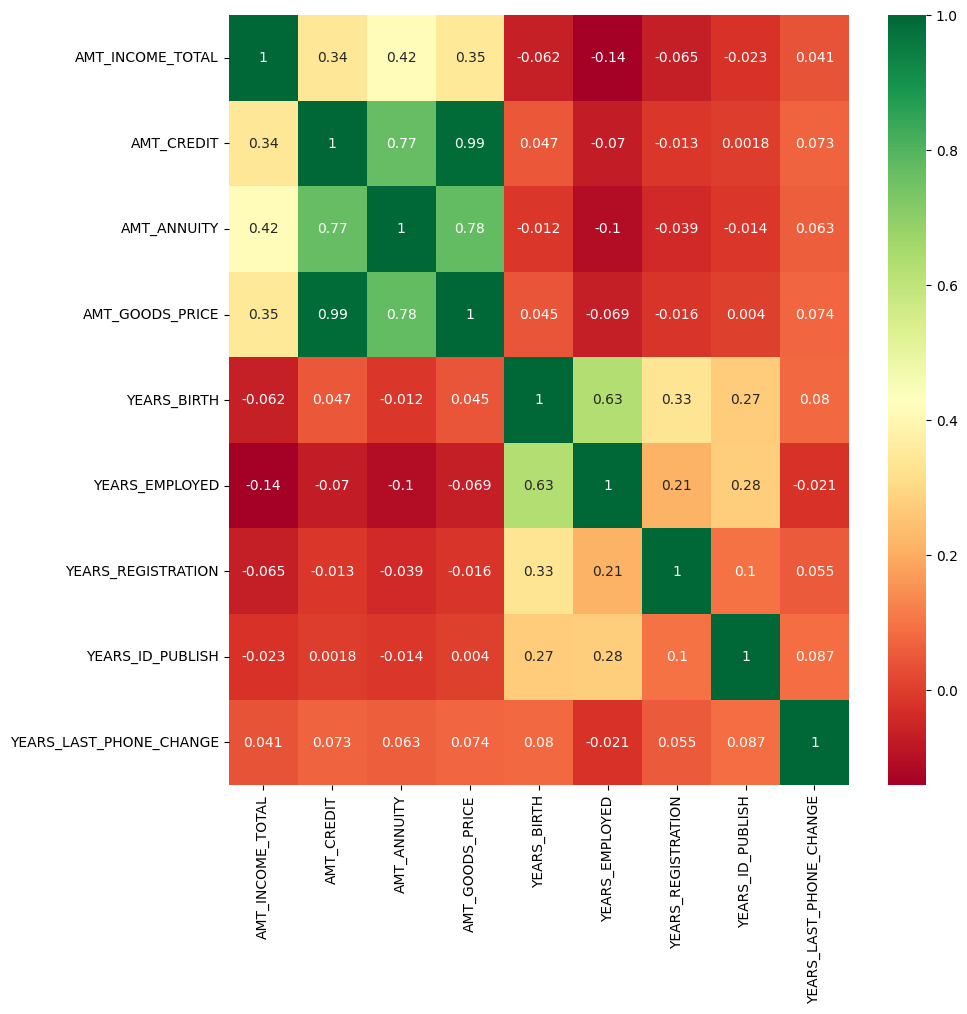

In [166]:
plt.figure(figsize = (10,10))
sns.heatmap(corr_data_0.corr(), annot=True, cmap="RdYlGn")
plt.show()


In [167]:
plt.show()

Conclusion >>
- AMT_INCOME_TOTAL
Shows a positive correlation index of 0.34, 0.42, and 0.35 with AMT_CREDIT, AMT_ANNUITY, and AMT_GOODS_PRICE respectively. It is negatively correlated with most of the other “Year” columns.
- AMT_CREDIT
Has strong positive correlations of 0.99 with AMT_GOODS_PRICE and 0.77 with AMT_ANNUITY.
- AMT_ANNUITY
Positively correlates with AMT_CREDIT (0.77) and AMT_GOODS_PRICE (0.78), and has negative correlations with most “Year” variables.
- AMT_GOODS_PRICE
Shares high positive correlation indices with AMT_ANNUITY (0.78) and AMT_CREDIT (0.99).


# READ PREVIOUS APPLICATION 

In [168]:
papp_data = pd.read_csv("previous_application.csv")
papp_data.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


## DATA INSPECTION

In [169]:
papp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [170]:
papp_data.shape

(1670214, 37)

## DATA QUALITY CHECK

In [171]:
papp_data.isnull().mean()*100

SK_ID_PREV                      0.000000
SK_ID_CURR                      0.000000
NAME_CONTRACT_TYPE              0.000000
AMT_ANNUITY                    22.286665
AMT_APPLICATION                 0.000000
AMT_CREDIT                      0.000060
AMT_DOWN_PAYMENT               53.636480
AMT_GOODS_PRICE                23.081773
WEEKDAY_APPR_PROCESS_START      0.000000
HOUR_APPR_PROCESS_START         0.000000
FLAG_LAST_APPL_PER_CONTRACT     0.000000
NFLAG_LAST_APPL_IN_DAY          0.000000
RATE_DOWN_PAYMENT              53.636480
RATE_INTEREST_PRIMARY          99.643698
RATE_INTEREST_PRIVILEGED       99.643698
NAME_CASH_LOAN_PURPOSE          0.000000
NAME_CONTRACT_STATUS            0.000000
DAYS_DECISION                   0.000000
NAME_PAYMENT_TYPE               0.000000
CODE_REJECT_REASON              0.000000
NAME_TYPE_SUITE                49.119754
NAME_CLIENT_TYPE                0.000000
NAME_GOODS_CATEGORY             0.000000
NAME_PORTFOLIO                  0.000000
NAME_PRODUCT_TYP

In [172]:
percentage = 49
threshold_p = int(((100-percentage)/100)*papp_data.shape[0]+1)
papp_df = papp_data.dropna(axis=1, thresh=threshold_p)
papp_df.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,17145.0,SATURDAY,15,Y,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,607500.0,THURSDAY,11,Y,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,112500.0,TUESDAY,11,Y,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,450000.0,MONDAY,7,Y,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,337500.0,THURSDAY,9,Y,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [173]:
papp_df.shape

(1670214, 32)

## IMPUTE THE MISSING VALUES

In [174]:
for cols in papp_df:
    if papp_df[cols].dtypes == np.int64 or papp_df[cols].dtypes == np.float64:  
        papp_df[cols] = papp_df[cols].apply(lambda x : abs(x))  

In [175]:
null_cols = list(papp_df.columns[papp_df.isna().any()])
len(null_cols)

11

In [176]:
papp_df.isnull().mean()*100

SK_ID_PREV                      0.000000
SK_ID_CURR                      0.000000
NAME_CONTRACT_TYPE              0.000000
AMT_ANNUITY                    22.286665
AMT_APPLICATION                 0.000000
AMT_CREDIT                      0.000060
AMT_GOODS_PRICE                23.081773
WEEKDAY_APPR_PROCESS_START      0.000000
HOUR_APPR_PROCESS_START         0.000000
FLAG_LAST_APPL_PER_CONTRACT     0.000000
NFLAG_LAST_APPL_IN_DAY          0.000000
NAME_CASH_LOAN_PURPOSE          0.000000
NAME_CONTRACT_STATUS            0.000000
DAYS_DECISION                   0.000000
NAME_PAYMENT_TYPE               0.000000
CODE_REJECT_REASON              0.000000
NAME_CLIENT_TYPE                0.000000
NAME_GOODS_CATEGORY             0.000000
NAME_PORTFOLIO                  0.000000
NAME_PRODUCT_TYPE               0.000000
CHANNEL_TYPE                    0.000000
SELLERPLACE_AREA                0.000000
NAME_SELLER_INDUSTRY            0.000000
CNT_PAYMENT                    22.286366
NAME_YIELD_GROUP

## BINNING OF CONTINUOUS VARIABLE

In [177]:
papp_df.AMT_CREDIT.describe()

count    1.670213e+06
mean     1.961140e+05
std      3.185746e+05
min      0.000000e+00
25%      2.416050e+04
50%      8.054100e+04
75%      2.164185e+05
max      6.905160e+06
Name: AMT_CREDIT, dtype: float64

In [178]:
papp_df["AMT_CREDIT_Category"] = pd.cut(papp_df.AMT_CREDIT, [0, 200000, 400000, 600000, 800000, 1000000], labels = ["very low credit", "low credit", "medium credit", "high credit", "very high credit"])

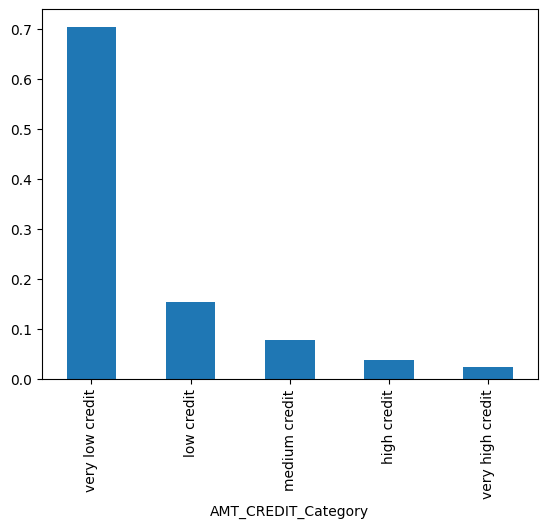

In [179]:
papp_df["AMT_CREDIT_Category"].value_counts(normalize = True).plot.bar()
plt.show()

conclusion : the credit amount of the loan for most of the applicants is either low(200000 to 400000)

In [180]:
papp_df["AMT_GOODS_PRICE_Category"] = pd.qcut(papp_df.AMT_GOODS_PRICE, q = [0, 0.25, 0.45, 0.65, 0.85, 1], labels = ["very low price", "low price", "medium price", "high price", "very high price"])

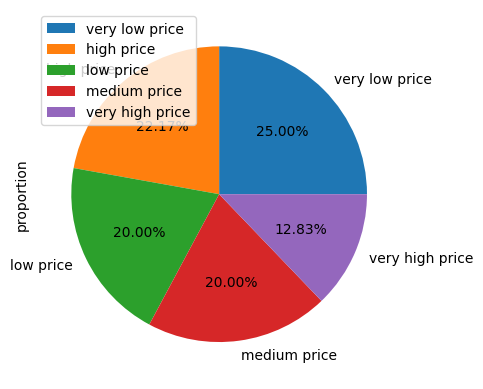

In [182]:
papp_df["AMT_GOODS_PRICE_Category"].value_counts(normalize=True).plot.pie(
    autopct='%1.2f%%'
)

plt.legend()
plt.show()

## DATA IMBALANCE CHECK

In [183]:
approved = papp_df[papp_df.NAME_CONTRACT_STATUS == "Approved"]
cancelled = papp_df[papp_df.NAME_CONTRACT_STATUS == "Cancelled"]
refused = papp_df[papp_df.NAME_CONTRACT_STATUS == "Refused"]
unused = papp_df[papp_df.NAME_CONTRACT_STATUS == "Unused Offer"]

In [184]:
papp_df.NAME_CONTRACT_STATUS.value_counts(normalize = True)*100

NAME_CONTRACT_STATUS
Approved        62.074740
Canceled        18.938831
Refused         17.403638
Unused offer     1.582791
Name: proportion, dtype: float64

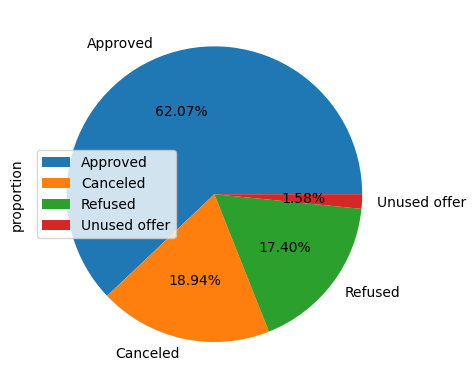

In [185]:
papp_df.NAME_CONTRACT_STATUS.value_counts(normalize = True).plot.pie(autopct = '%1.2F%%')
plt.legend()
plt.show()

conclusion : 62% of the applicant have the loan apporved. 17% applicants are rejected and 2% are unused 

In [186]:
## UNIVARIATE ANALYSIS 

In [187]:
cat_cols = list(papp_df.columns[papp_df.dtypes == object])  # Changed np.object to object
num_cols = list(papp_df.columns[papp_df.dtypes == np.int64]) + list(papp_df.columns[papp_df.dtypes == np.float64])

In [188]:
cat_cols

['NAME_CONTRACT_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'FLAG_LAST_APPL_PER_CONTRACT',
 'NAME_CASH_LOAN_PURPOSE',
 'NAME_CONTRACT_STATUS',
 'NAME_PAYMENT_TYPE',
 'CODE_REJECT_REASON',
 'NAME_CLIENT_TYPE',
 'NAME_GOODS_CATEGORY',
 'NAME_PORTFOLIO',
 'NAME_PRODUCT_TYPE',
 'CHANNEL_TYPE',
 'NAME_SELLER_INDUSTRY',
 'NAME_YIELD_GROUP',
 'PRODUCT_COMBINATION']

In [189]:
num_cols

['SK_ID_PREV',
 'SK_ID_CURR',
 'HOUR_APPR_PROCESS_START',
 'NFLAG_LAST_APPL_IN_DAY',
 'DAYS_DECISION',
 'SELLERPLACE_AREA',
 'AMT_ANNUITY',
 'AMT_APPLICATION',
 'AMT_CREDIT',
 'AMT_GOODS_PRICE',
 'CNT_PAYMENT',
 'DAYS_FIRST_DRAWING',
 'DAYS_FIRST_DUE',
 'DAYS_LAST_DUE_1ST_VERSION',
 'DAYS_LAST_DUE',
 'DAYS_TERMINATION',
 'NFLAG_INSURED_ON_APPROVAL']

In [190]:
cat_cols = ['NAME_CONTRACT_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'NAME_CONTRACT_STATUS',
 'NAME_PAYMENT_TYPE',
 'NAME_CLIENT_TYPE',
 'NAME_SELLER_INDUSTRY',
 'NAME_YIELD_GROUP',
 'PRODUCT_COMBINATION']

In [191]:
num_cols = ['HOUR_APPR_PROCESS_START',
 'DAYS_DECISION',
 'AMT_ANNUITY',
 'AMT_APPLICATION',
 'AMT_CREDIT',
 'AMT_GOODS_PRICE',
 'CNT_PAYMENT']

NAME_CONTRACT_TYPE
Cash loans         44.757917
Consumer loans     43.656142
Revolving loans    11.565225
XNA                 0.020716
Name: proportion, dtype: float64


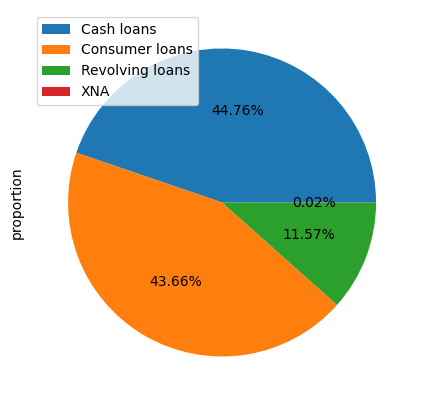

WEEKDAY_APPR_PROCESS_START
TUESDAY      15.274570
WEDNESDAY    15.268103
MONDAY       15.181109
FRIDAY       15.090761
THURSDAY     14.914197
SATURDAY     14.407196
SUNDAY        9.864065
Name: proportion, dtype: float64


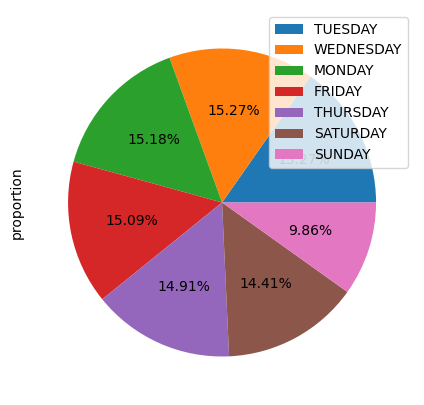

NAME_CONTRACT_STATUS
Approved        62.074740
Canceled        18.938831
Refused         17.403638
Unused offer     1.582791
Name: proportion, dtype: float64


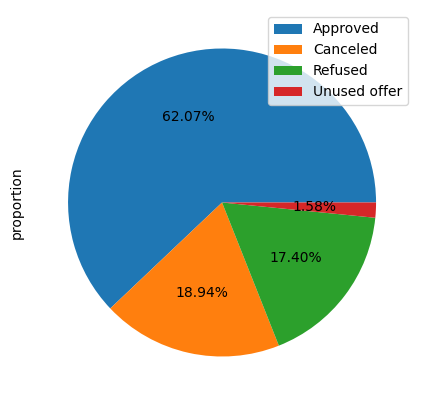

NAME_PAYMENT_TYPE
Cash through the bank                        61.881412
XNA                                          37.563091
Non-cash from your account                    0.490536
Cashless from the account of the employer     0.064962
Name: proportion, dtype: float64


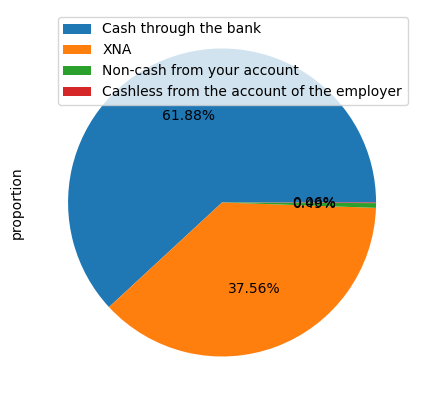

NAME_CLIENT_TYPE
Repeater     73.718757
New          18.043376
Refreshed     8.121654
XNA           0.116213
Name: proportion, dtype: float64


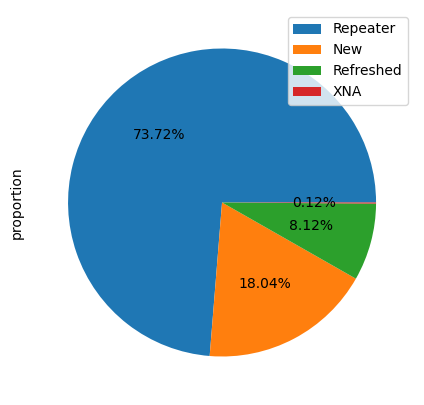

NAME_SELLER_INDUSTRY
XNA                     51.234153
Consumer electronics    23.845148
Connectivity            16.526565
Furniture                3.463568
Construction             1.783065
Clothing                 1.433888
Industry                 1.149194
Auto technology          0.298764
Jewelry                  0.162195
MLM partners             0.072745
Tourism                  0.030715
Name: proportion, dtype: float64


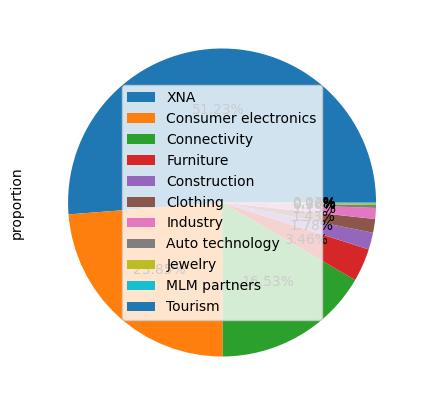

NAME_YIELD_GROUP
XNA           30.966990
middle        23.082791
high          21.154834
low_normal    19.284655
low_action     5.510731
Name: proportion, dtype: float64


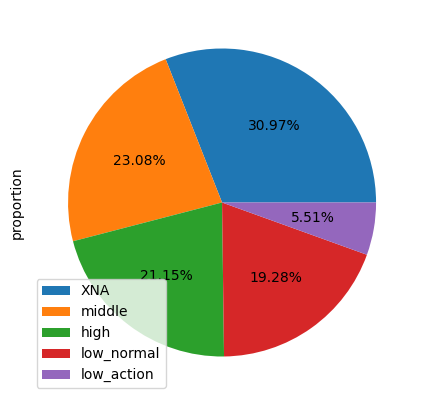

PRODUCT_COMBINATION
Cash                              17.126503
POS household with interest       15.786996
POS mobile with interest          13.214817
Cash X-Sell: middle                8.616430
Cash X-Sell: low                   7.799898
Card Street                        6.741970
POS industry with interest         5.918612
POS household without interest     4.964943
Card X-Sell                        4.825651
Cash Street: high                  3.571480
Cash X-Sell: high                  3.551239
Cash Street: middle                2.075493
Cash Street: low                   2.026148
POS mobile without interest        1.442150
POS other with interest            1.429993
POS industry without interest      0.754670
POS others without interest        0.153006
Name: proportion, dtype: float64


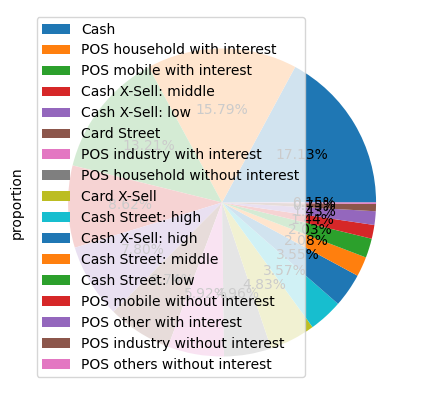

In [192]:
for col in cat_cols: 
    print(papp_df[col].value_counts(normalize = True)*100)
    plt.figure(figsize = [5,5])
    papp_df[col].value_counts(normalize = True).plot.pie(labeldistance = None, autopct = '%1.2f%%')
    plt.legend()
    plt.show()

Conclusion >> Previous Loan Application Summary
- NAME_CONTRACT_TYPE
- 45% received Cash loans
- 44% received Consumer loans
- 12% received Revolving credit
- WEEKDAY_APPR_PROCESS_START
- Loan applications are nearly evenly distributed across all weekdays
- NAME_CONTRACT_STATUS
- 62% Approved, 19% Cancelled, 17% Refused, 2% Unused
- NAME_PAYMENT_TYPE
- 62% used Cash through bank
- 32% used Other payment types
- NAME_CLIENT_TYPE
- 74% were Repeaters, 18% New applicants, 8% Refreshed applicants
- NAME_SELLER_INDUSTRY
- 51% from Other industries
- 24% Consumer electronics, 17% Connectivity industry
- CHANNEL_TYPE
- 43% from Credit and cash offices
- 29% from Country-wide channels
- NAME_YIELD_GROUP
- Majority fall under Other category
- PRODUCT_COMBINATION
- Most common: Cash
- Followed by: POS household with interest and POS mobile with interest


99th percentile 20.0
count    1.670214e+06
mean     1.248418e+01
std      3.334028e+00
min      0.000000e+00
25%      1.000000e+01
50%      1.200000e+01
75%      1.500000e+01
max      2.300000e+01
Name: HOUR_APPR_PROCESS_START, dtype: float64


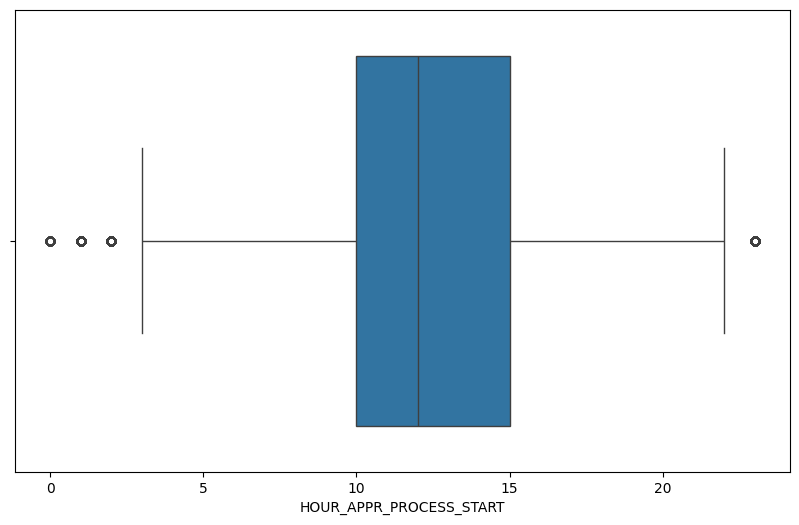

99th percentile 2835.0
count    1.670214e+06
mean     8.806797e+02
std      7.790997e+02
min      1.000000e+00
25%      2.800000e+02
50%      5.810000e+02
75%      1.300000e+03
max      2.922000e+03
Name: DAYS_DECISION, dtype: float64


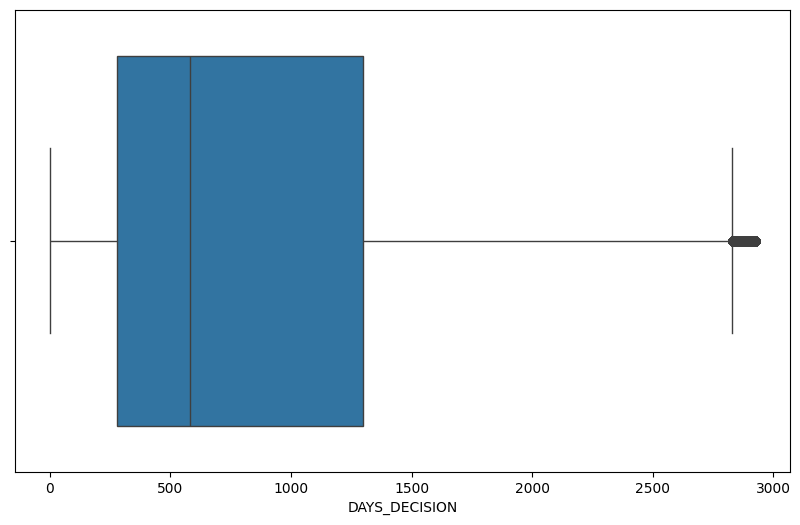

99th percentile nan
count    1.297979e+06
mean     1.595512e+04
std      1.478214e+04
min      0.000000e+00
25%      6.321780e+03
50%      1.125000e+04
75%      2.065842e+04
max      4.180581e+05
Name: AMT_ANNUITY, dtype: float64


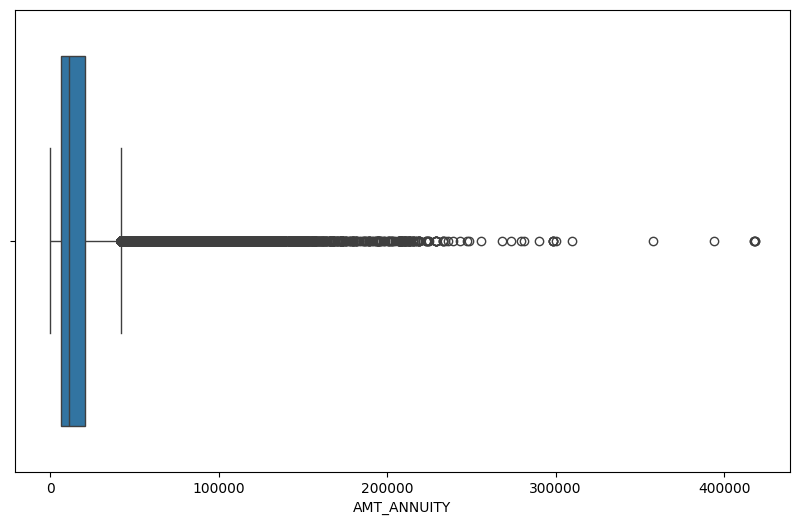

99th percentile 1350000.0
count    1.670214e+06
mean     1.752339e+05
std      2.927798e+05
min      0.000000e+00
25%      1.872000e+04
50%      7.104600e+04
75%      1.803600e+05
max      6.905160e+06
Name: AMT_APPLICATION, dtype: float64


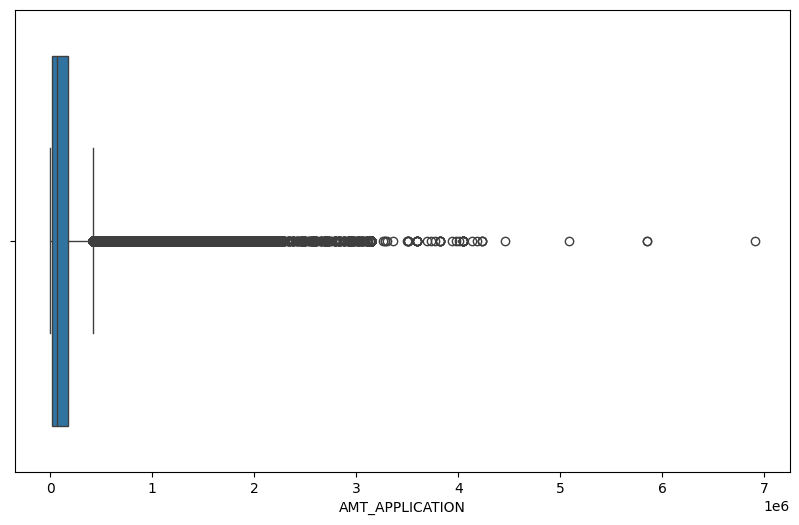

99th percentile nan
count    1.670213e+06
mean     1.961140e+05
std      3.185746e+05
min      0.000000e+00
25%      2.416050e+04
50%      8.054100e+04
75%      2.164185e+05
max      6.905160e+06
Name: AMT_CREDIT, dtype: float64


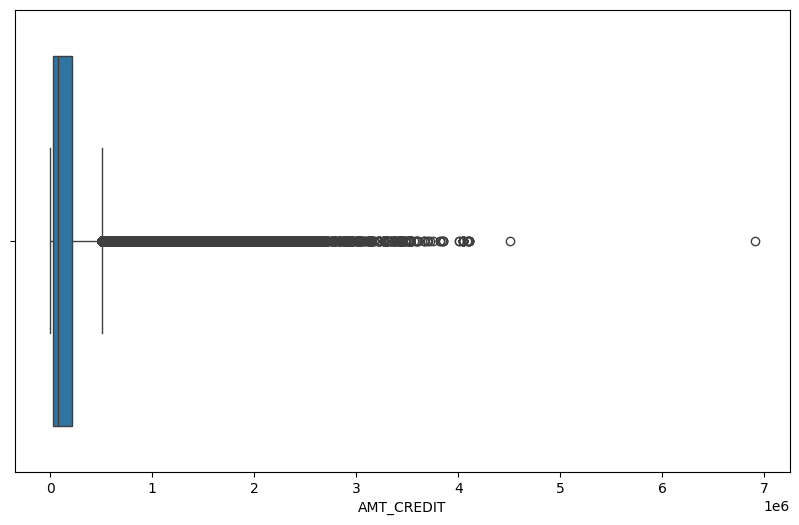

99th percentile nan
count    1.284699e+06
mean     2.278473e+05
std      3.153966e+05
min      0.000000e+00
25%      5.084100e+04
50%      1.123200e+05
75%      2.340000e+05
max      6.905160e+06
Name: AMT_GOODS_PRICE, dtype: float64


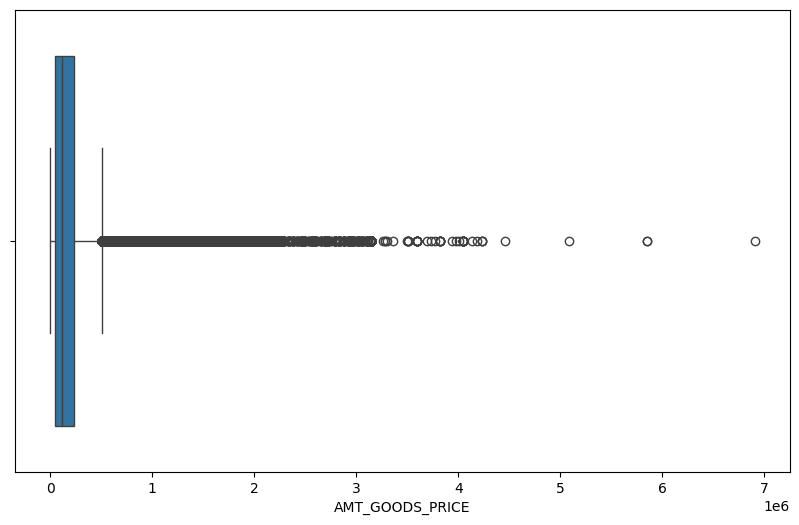

99th percentile nan
count    1.297984e+06
mean     1.605408e+01
std      1.456729e+01
min      0.000000e+00
25%      6.000000e+00
50%      1.200000e+01
75%      2.400000e+01
max      8.400000e+01
Name: CNT_PAYMENT, dtype: float64


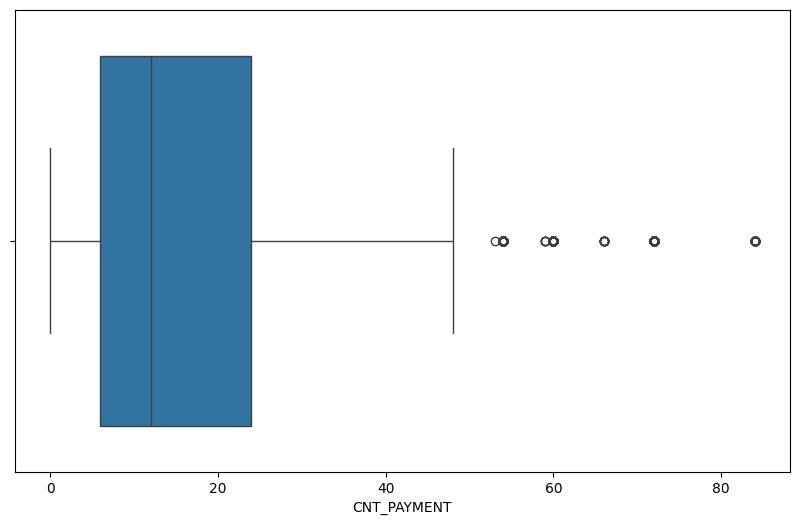

In [193]:
for cols in num_cols:
    print("99th percentile", np.percentile(papp_df[cols], 99))
    print(papp_df[cols].describe())
    plt.figure(figsize = [10,6])
    sns.boxplot(data = papp_df, x = cols)
    plt.show()


Conclusion >> Few Columns with Outliers Are Below
- HOUR_APPR_PROCESS_START
- Has a few outliers.
- Small difference between mean and median.
- AMT_CREDIT
- Few outliers present.
- Large gap between 99th percentile and max value.
- Significant difference between mean and median due to outliers.
- AMT_ANNUITY
- Outliers exist.
- Large difference between 99th percentile and max value.
- Notable mean-median variation caused by outliers.
- AMT_GOODS_PRICE
- Affected by outliers.
- Substantial spread between 99th percentile and max.
- Pronounced mean vs. median difference.
- AMT_APPLICATION
- Few outliers.
- Marked difference between 99th percentile and max value.
- Clear impact on mean and median.
- CNT_PAYMENT
- Contains outliers.
- Small gap between mean and median.
- DAYS_DECISION
- Displays some outliers.
- Minor difference between mean and median.




## BIVARIATE AND MULTIVARIATE ANALYSIS 

In [194]:
prev_app = pd.read_csv('previous_application.csv')

print(prev_app['NAME_CONTRACT_STATUS'].unique())

approved = prev_app[prev_app['NAME_CONTRACT_STATUS'] == 'Approved']
refused = prev_app[prev_app['NAME_CONTRACT_STATUS'] == 'Refused']
cancelled = prev_app[prev_app['NAME_CONTRACT_STATUS'] == 'Canceled']
unused = prev_app[prev_app['NAME_CONTRACT_STATUS'] == 'Unused offer']


['Approved' 'Refused' 'Canceled' 'Unused offer']


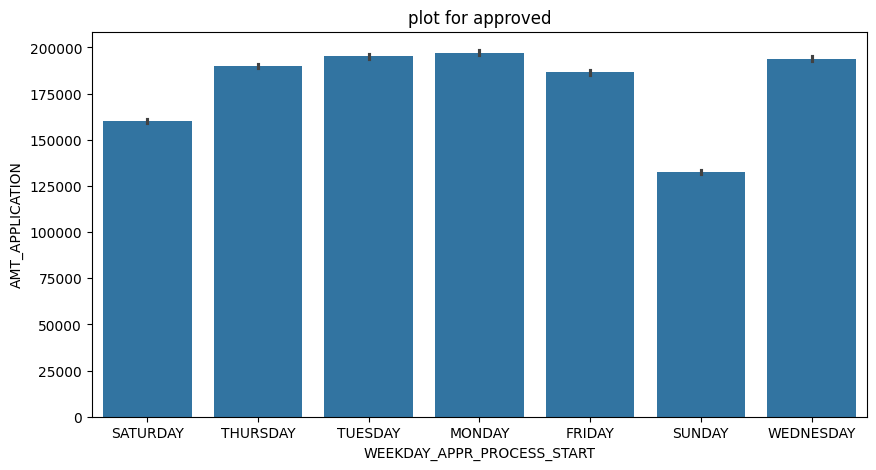

In [195]:
plt.figure(figsize = [10,5])
sns.barplot(x = 'WEEKDAY_APPR_PROCESS_START', y = 'AMT_APPLICATION', data = approved)
plt.title("plot for approved")
plt.show()

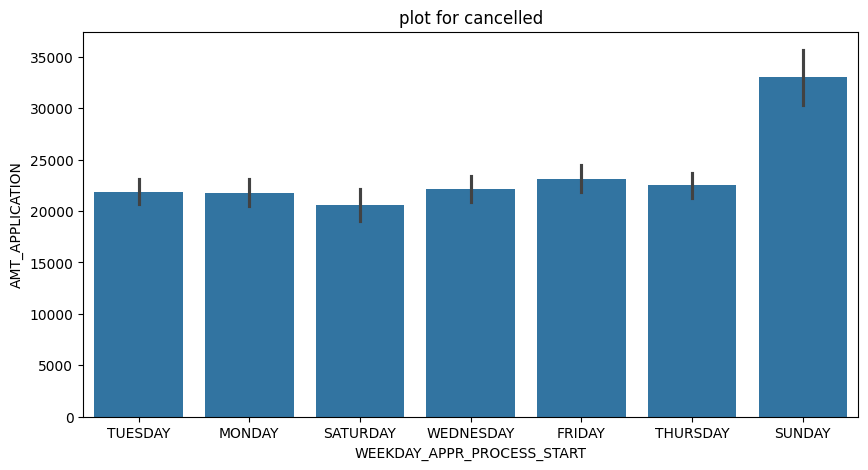

In [196]:
plt.figure(figsize = [10,5])
sns.barplot(x = 'WEEKDAY_APPR_PROCESS_START', y = 'AMT_APPLICATION', data = cancelled)
plt.title("plot for cancelled")
plt.show()

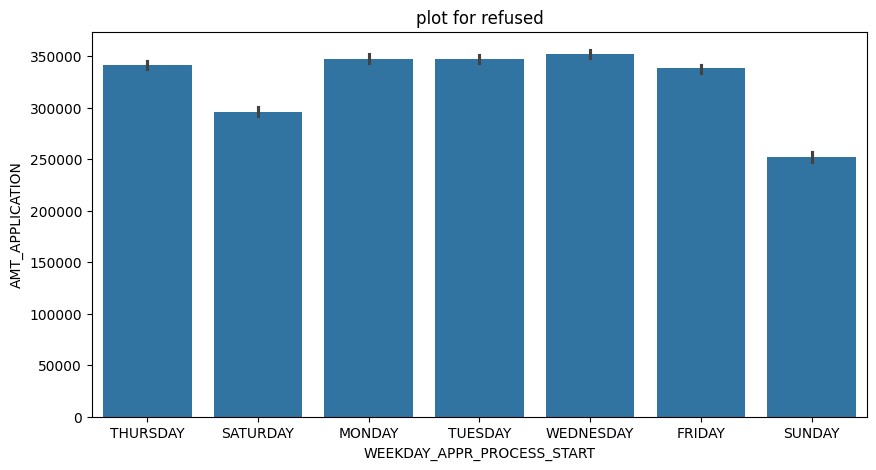

In [197]:
plt.figure(figsize = [10,5])
sns.barplot(x = 'WEEKDAY_APPR_PROCESS_START', y = 'AMT_APPLICATION', data = refused)
plt.title("plot for refused")
plt.show()

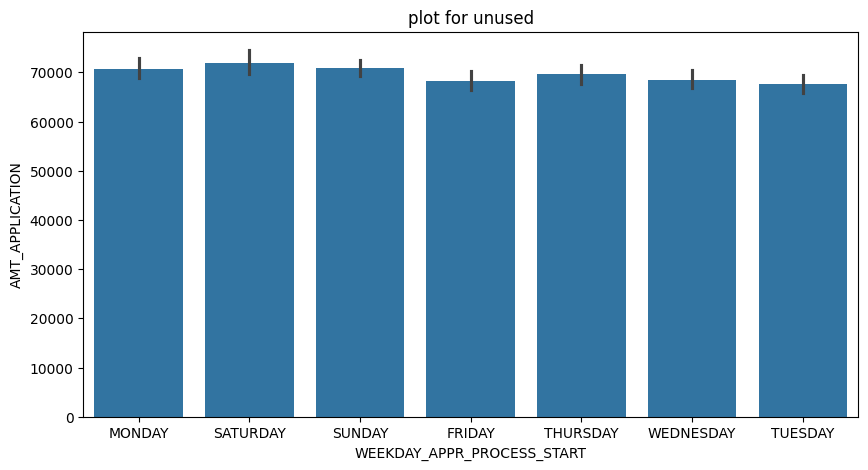

In [198]:
plt.figure(figsize = [10,5])
sns.barplot(x = 'WEEKDAY_APPR_PROCESS_START', y = 'AMT_APPLICATION', data = unused)
plt.title("plot for unused")
plt.show()

- Approved applicants tend to have higher credit amounts on Monday and Wednesday, and the lowest on Sunday.
- For cancelled statuses, credit amounts peak on Sunday and are otherwise fairly uniform.
- Rejected applicants see higher credit amounts on Monday and Wednesday, with the lowest on Sunday.
- Unused offers show nearly uniform credit amounts throughout the week.

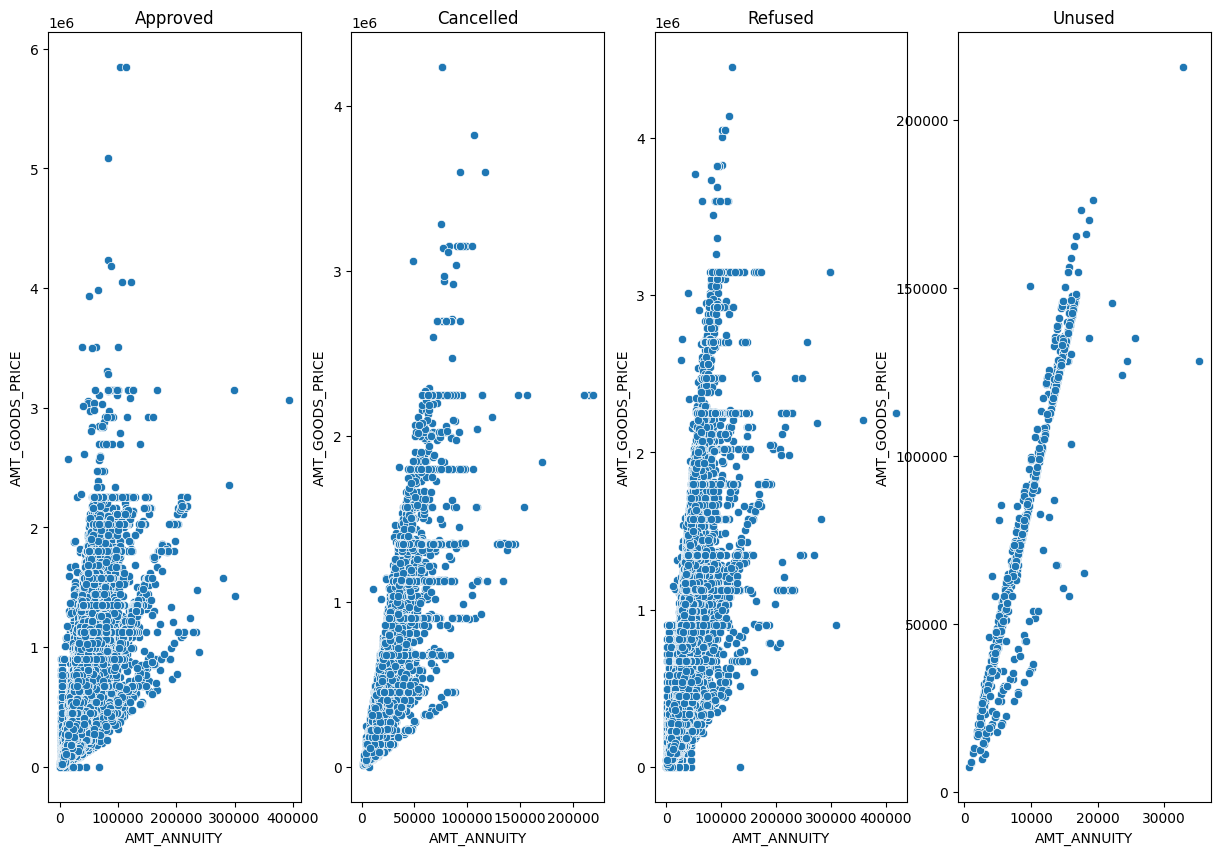

In [199]:
plt.figure(figsize=(15,10))
plt.subplot(1,4,1)
plt.title("Approved")
sns.scatterplot(x='AMT_ANNUITY', y='AMT_GOODS_PRICE', data=approved)

plt.subplot(1,4,2)
plt.title("Cancelled")
sns.scatterplot(x='AMT_ANNUITY', y='AMT_GOODS_PRICE', data=cancelled)

plt.subplot(1,4,3)
plt.title("Refused")
sns.scatterplot(x='AMT_ANNUITY', y='AMT_GOODS_PRICE', data=refused)

plt.subplot(1,4,4)
plt.title("Unused")
sns.scatterplot(x='AMT_ANNUITY', y='AMT_GOODS_PRICE', data=unused)

plt.show()

In [200]:
corr_approved = approved[["DAYS_DECISION", "AMT_ANNUITY", "AMT_APPLICATION", "AMT_CREDIT", "AMT_GOODS_PRICE", "CNT_PAYMENT"]]
corr_refused = refused[["DAYS_DECISION", "AMT_ANNUITY", "AMT_APPLICATION", "AMT_CREDIT", "AMT_GOODS_PRICE", "CNT_PAYMENT"]]
corr_cancelled = cancelled[["DAYS_DECISION", "AMT_ANNUITY", "AMT_APPLICATION", "AMT_CREDIT", "AMT_GOODS_PRICE", "CNT_PAYMENT"]]
corr_unused = unused[["DAYS_DECISION", "AMT_ANNUITY", "AMT_APPLICATION", "AMT_CREDIT", "AMT_GOODS_PRICE", "CNT_PAYMENT"]]

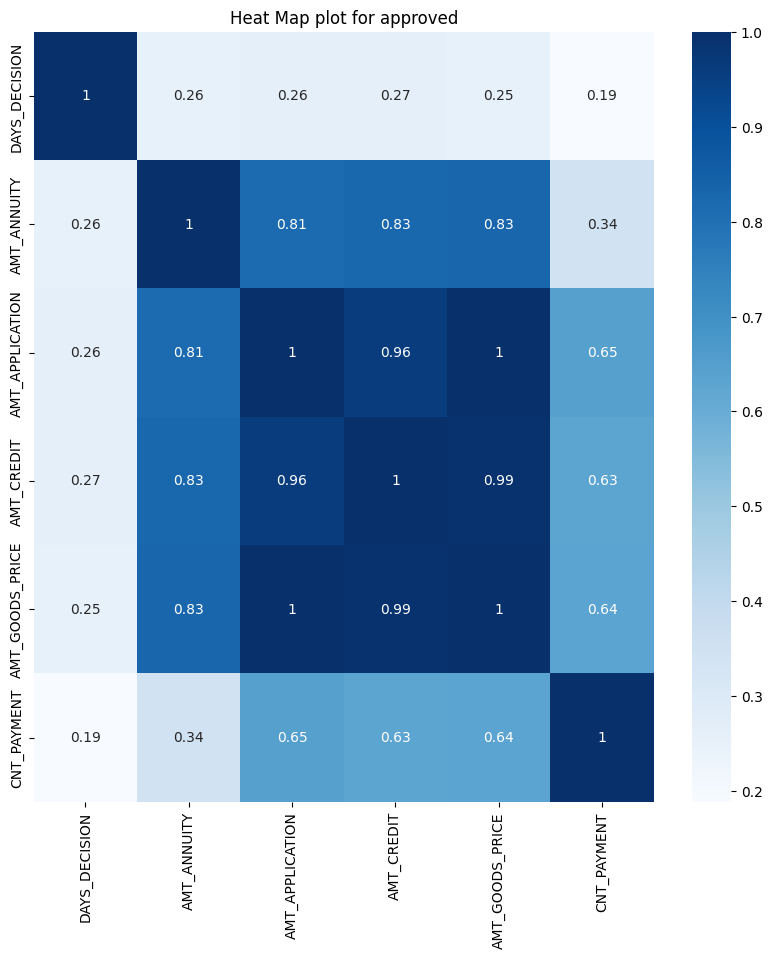

In [201]:
plt.figure(figsize = [10,10])
sns.heatmap(corr_approved.corr(), annot=True, cmap='Blues')  
plt.title("Heat Map plot for approved")
plt.show()

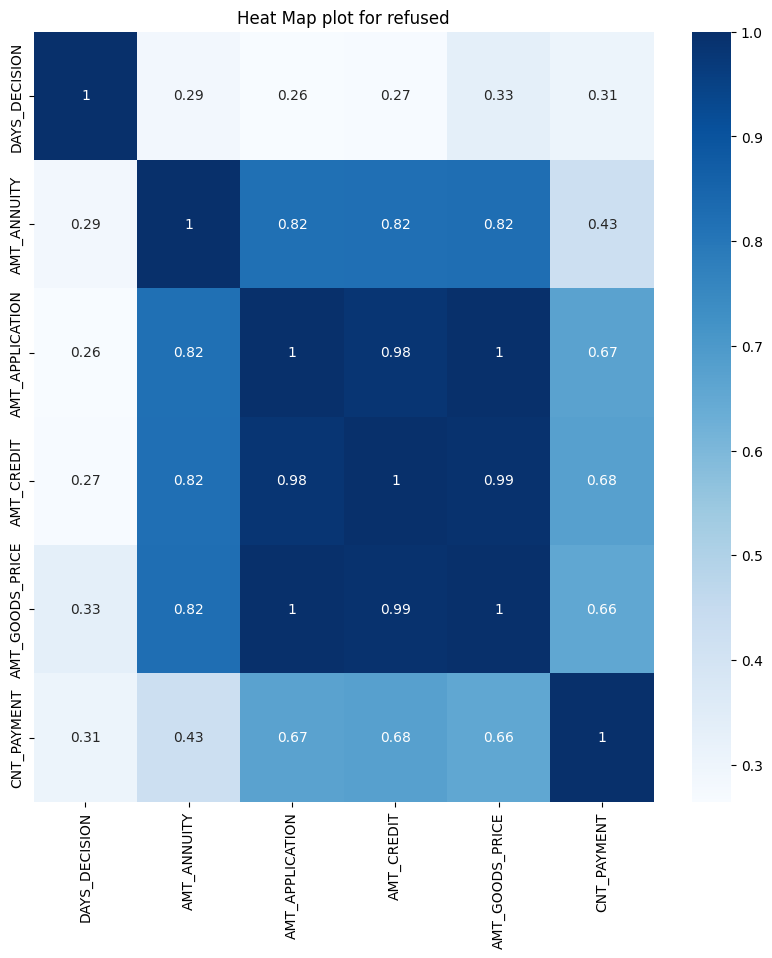

In [202]:
plt.figure(figsize = [10,10])
sns.heatmap(corr_refused.corr(), annot=True, cmap='Blues')  
plt.title("Heat Map plot for refused")
plt.show()

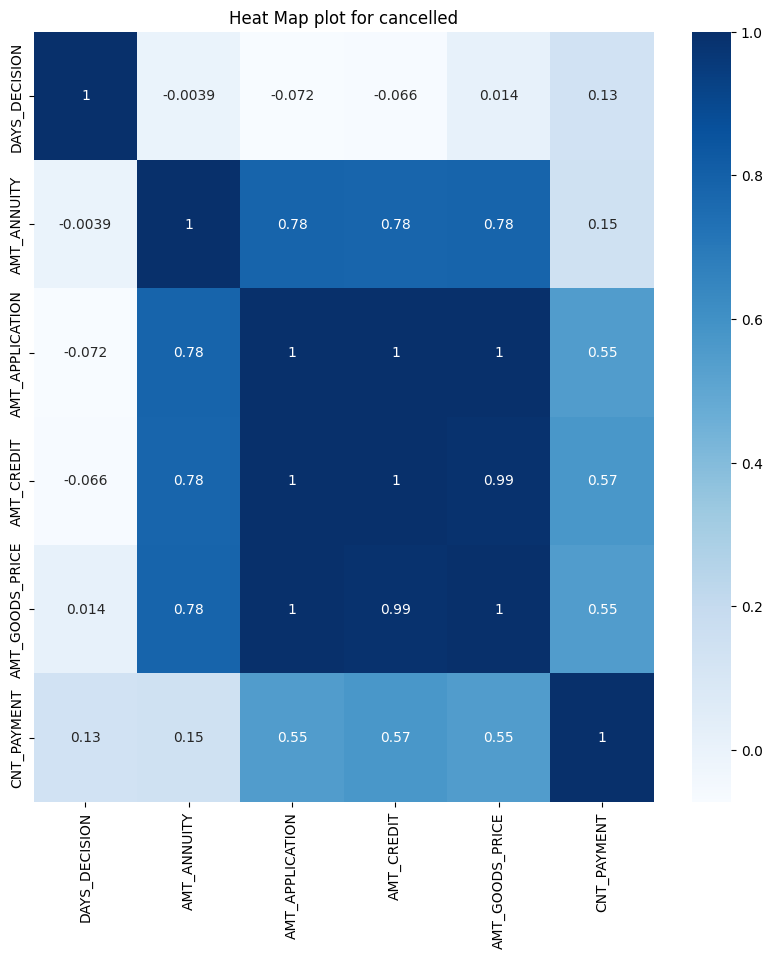

In [203]:
plt.figure(figsize = [10,10])
sns.heatmap(corr_cancelled.corr(), annot=True, cmap='Blues')  
plt.title("Heat Map plot for cancelled")
plt.show()

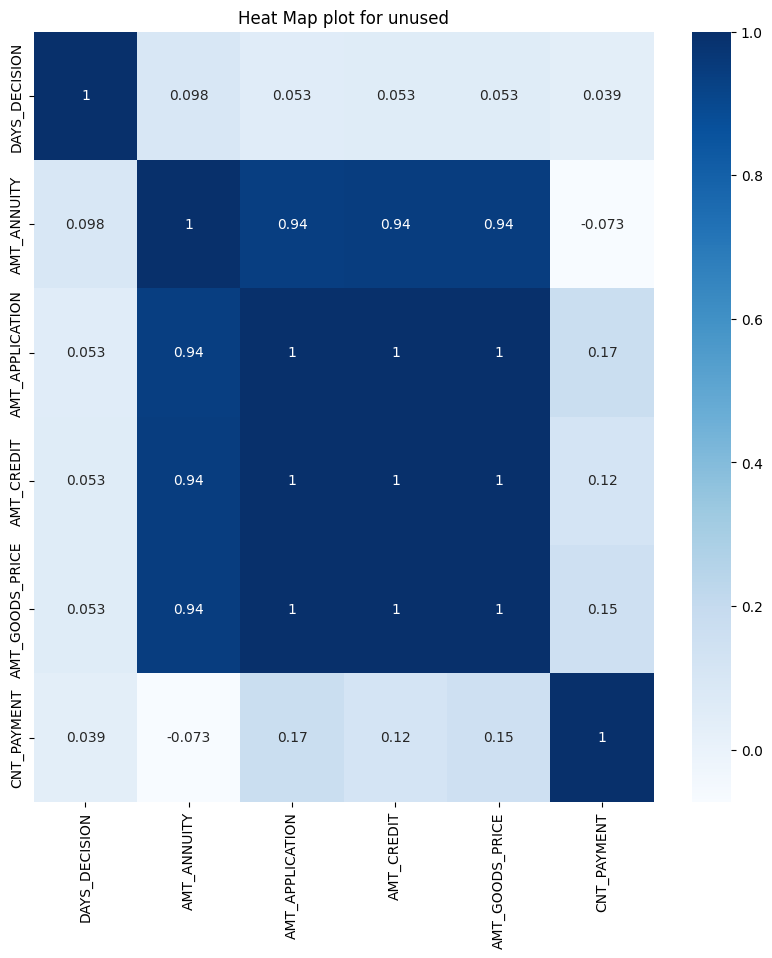

In [204]:
plt.figure(figsize = [10,10])
sns.heatmap(corr_unused.corr(), annot=True, cmap='Blues')  
plt.title("Heat Map plot for unused")
plt.show()

# MERGING THE APPLICATION AND PREVIOUS APPLICATION DATA FRAME

In [205]:
merge_df = app_df.merge(papp_df, on=["SK_ID_CURR"], how='left')
merge_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE_x,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_x,AMT_ANNUITY_x,...,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL,AMT_CREDIT_Category,AMT_GOODS_PRICE_Category
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,low_normal,POS other with interest,365243.0,565.0,125.0,25.0,17.0,0.0,very low credit,high price
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,low_normal,Cash X-Sell: low,365243.0,716.0,386.0,536.0,527.0,1.0,NaN,very high price
2,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,middle,POS industry with interest,365243.0,797.0,647.0,647.0,639.0,0.0,low credit,high price
3,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,middle,POS household with interest,365243.0,2310.0,1980.0,1980.0,1976.0,1.0,very low credit,low price
4,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,middle,POS mobile without interest,365243.0,784.0,694.0,724.0,714.0,0.0,very low credit,very low price


In [206]:
merge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430155 entries, 0 to 1430154
Columns: 113 entries, SK_ID_CURR to AMT_GOODS_PRICE_Category
dtypes: category(4), float64(36), int64(46), object(27)
memory usage: 1.2+ GB


# FILTERATION

In [207]:
for col in merge_df.columns:
    if col.startswith("FLAG"):
        merge_df.drop(columns = col, axis = 1, inplace = True)
        

In [208]:
merge_df.shape

(1430155, 84)

In [209]:
res1 = pd.pivot_table(data = merge_df, index = ["NAME_INCOME_TYPE", "NAME_CLIENT_TYPE"], columns = ["NAME_CONTRACT_STATUS"], values = "TARGET", aggfunc = "mean")

In [210]:
res1

NAME_CONTRACT_STATUS                   Approved  Canceled   Refused  \
NAME_INCOME_TYPE     NAME_CLIENT_TYPE                                 
Commercial associate New               0.083012  0.151452  0.096548   
                     Refreshed         0.059167  0.074328  0.105068   
                     Repeater          0.068442  0.084824  0.112279   
                     XNA               0.090909  0.084337  0.062500   
Maternity leave      New               1.000000       NaN       NaN   
                     Repeater          1.000000  1.000000  1.000000   
Pensioner            New               0.057211  0.112805  0.060098   
                     Refreshed         0.046378  0.058281  0.089165   
                     Repeater          0.051421  0.060693  0.078492   
                     XNA               0.010101  0.047872  0.116279   
State servant        New               0.061750  0.090226  0.047745   
                     Refreshed         0.044057  0.045317  0.083756   
                     Repeater          0.056430  0.072019  0.088759   
                     XNA               0.062500  0.023256  0.000000   
Student              New               0.000000       NaN       NaN   
                     Refreshed         0.000000       NaN       NaN   
                     Repeater          0.000000  0.000000  0.000000   
Unemployed           New               0.500000       NaN  0.500000   
                     Refreshed         0.000000       NaN       NaN   
                     Repeater          0.460000  0.687500  0.666667   
Working              New               0.104073  0.153177  0.135940   
                     Refreshed         0.077033  0.098898  0.134548   
                     Repeater          0.084077  0.111727  0.143000   
                     XNA               0.092593  0.141791  0.185897   

NAME_CONTRACT_STATUS                   Unused offer  
NAME_INCOME_TYPE     NAME_CLIENT_TYPE                
Commercial associate New                   0.070485  
                     Refreshed             0.052774  
                     Repeater              0.068921  
                     XNA                   0.200000  
Maternity leave      New                        NaN  
                     Repeater              1.000000  
Pensioner            New                   0.062857  
                     Refreshed             0.044521  
                     Repeater              0.053645  
                     XNA                   0.000000  
State servant        New                   0.080357  
                     Refreshed             0.081967  
                     Repeater              0.067183  
                     XNA                   0.000000  
Student              New                        NaN  
                     Refreshed                  NaN  
                     Repeater                   NaN  
Unemployed           New                        NaN  
                     Refreshed                  NaN  
                     Repeater              0.000000  
Working              New                   0.102131  
                     Refreshed             0.085016  
                     Repeater              0.093989  
                     XNA                   0.100000

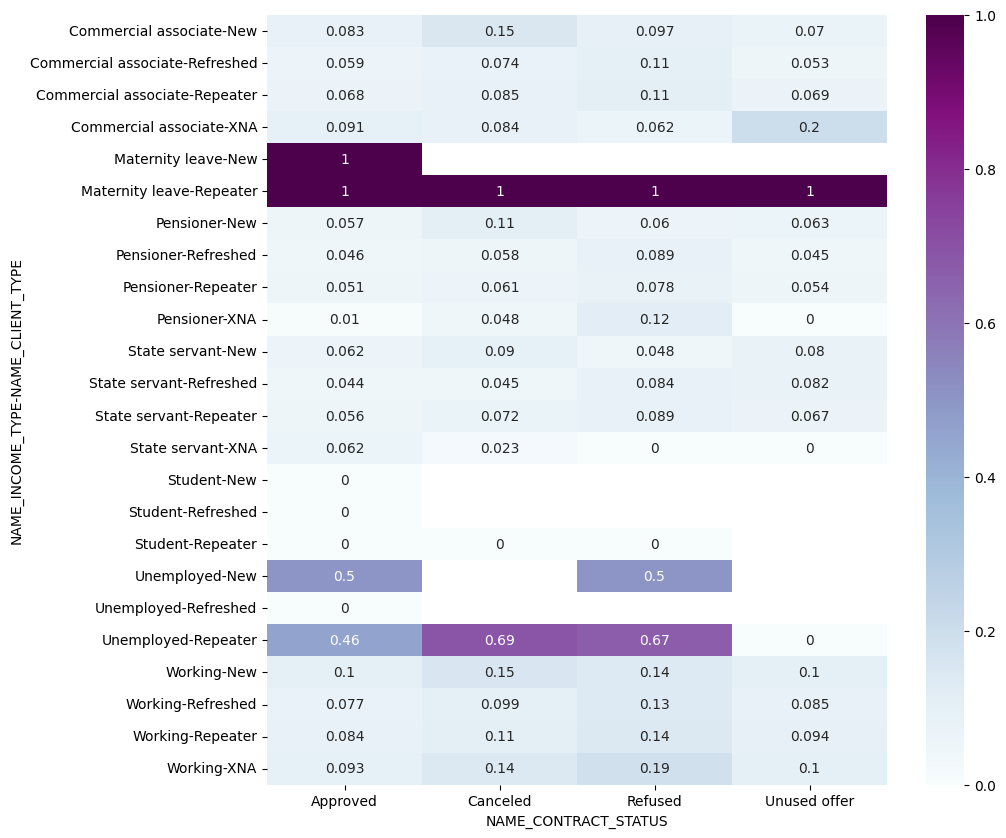

In [211]:
plt.figure(figsize = [10,10])
sns.heatmap(res1, annot = True, cmap = "BuPu")
plt.show()

- Applicants on maternity leave and marked as new clients are more likely to have their loan approved.
- Those who are unemployed or on maternity leave, and are repeat clients, often have their loans cancelled.
- Similar applicants (unemployed/maternity leave with repeater status) tend to get refused.
- Offers are not being utilized by applicants who are:
- on maternity leave with repeater status, or
- working with new client status.


In [214]:
res2 = pd.pivot_table(
    data=merge_df,
    index=["CODE_GENDER", "NAME_SELLER_INDUSTRY"],
    columns=["TARGET"],
    values="AMT_GOODS_PRICE_Category",
    aggfunc="count"
)

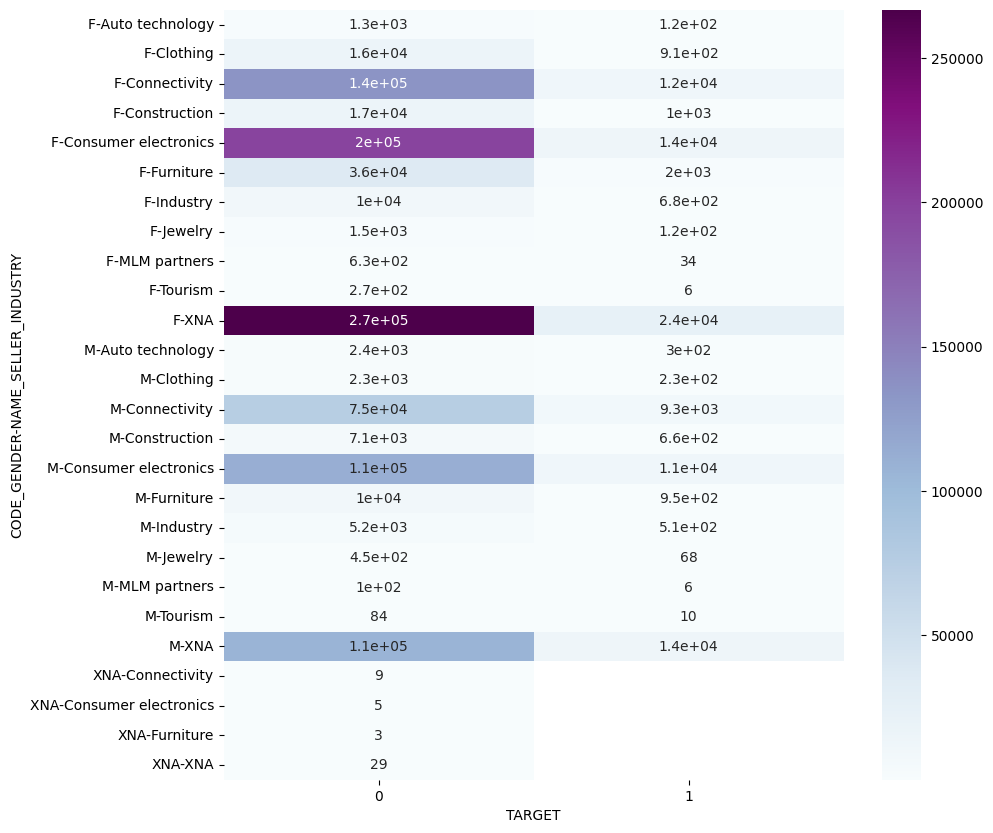

In [215]:
plt.figure(figsize = [10,10])
sns.heatmap(res2, annot = True, cmap = "BuPu")
plt.show()

In [216]:
# Model Training - using merged dataframe
from sklearn.model_selection import train_test_split

# Drop non-predictive and target columns
drop_cols = ["TARGET", "SK_ID_CURR"]
X = merge_df.select_dtypes(include=["int64", "float64"]).drop(columns=drop_cols, errors="ignore")
y = merge_df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (1144124, 54), Test shape: (286031, 54)
